# Welcome to the AIMS Jupyter Notebook!
# As a refresher, hit ctrl + enter to run each cell
I tried to add comments and other markdown cells like this one where appropriate to help with interpretations

# Section 0: Loading in Modules and Defining Figure Formatting
This first cell is just loading in all of the necessary python modules (which you should have already installed) and defining figure font, size, etc.

In [1]:
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as pl
from matplotlib import rcParams
from matplotlib import rc
from matplotlib.lines import Line2D
from mpl_toolkits import mplot3d
import pandas
from sklearn.utils import resample
import matplotlib.gridspec as gridspec

# THIS LAST BIT IS TO NAVIAGATE TO WHERE MY CUSTOM MODULES ARE LOCATED
import os
from aims_immune import aims_loader as aimsLoad
from aims_immune import aims_analysis as aims
from aims_immune import aims_classification as classy
from aims_immune import aims_utils as utils

import aims_immune
aimsDir = aims_immune.__file__[:-11]

# This bit is for that figure formatting. Change font and font size if desired
font = {'family' : 'Arial',
        'weight' : 'bold',
        'size'   : 20}
COLOR = 'black'
rcParams['text.color'] = 'black'
rcParams['axes.labelcolor'] = COLOR
rcParams['xtick.color'] = COLOR
rcParams['ytick.color'] = COLOR

rc('font', **font)

# Lastly this custom colormap is for 
import matplotlib as mpl
upper = mpl.cm.jet(np.arange(256))
lower = np.ones((int(256/4),4))
for i in range(3):
    lower[:,i] = np.linspace(1, upper[0,i], lower.shape[0])
cmap = np.vstack(( lower, upper ))
cmap = mpl.colors.ListedColormap(cmap, name='myColorMap', N=cmap.shape[0])

# Section 1: Data Input
Define your input data and output directory

In [33]:
datDir = 'app_data/'
outputDir = "AIMS_outs"

try: 
    os.listdir(outputDir)
except:
    os.makedirs(outputDir)

# Molecule can be 'Ig', 'msa', or 'peptide'
molecule = 'msa'
fileName = ["test_data/abs/flu_poly.csv","test_data/abs/flu_mono.csv"]
datName = ["Poly","Mono"]
# Do you want AIMS to drop duplicate sequences (clonal expansion or otherwise)?
drop_duplicates = False
# Parallel processing via numba. 
parallel_process = True

if len(fileName) != len(datName):
    print("A mistake! You don't have the proper number of labels for your files")

seqF,xtick_loc,AA_num_key,mat_size = utils.loadDat(fileName,datName,datDir,drop_duplicates)
# Include a custom ordering of amino acid encodings here if you'd like
my_AA_key,my_AA_key_dash = utils.get_keys()

# Section 2: Sequence Visualization via AIMS Matrix Encoding

If looking at Ig molecules, you can decide if you would like to align to the center, left, or right of each sequence.

There is a 3rd option, "bulge" which aligns the germline regions of CDR3 (and other loops) and then center aligns what is left. 

Change the 'align' variable to one of these four. Pretty easy to visualize each time you do so in below matrix

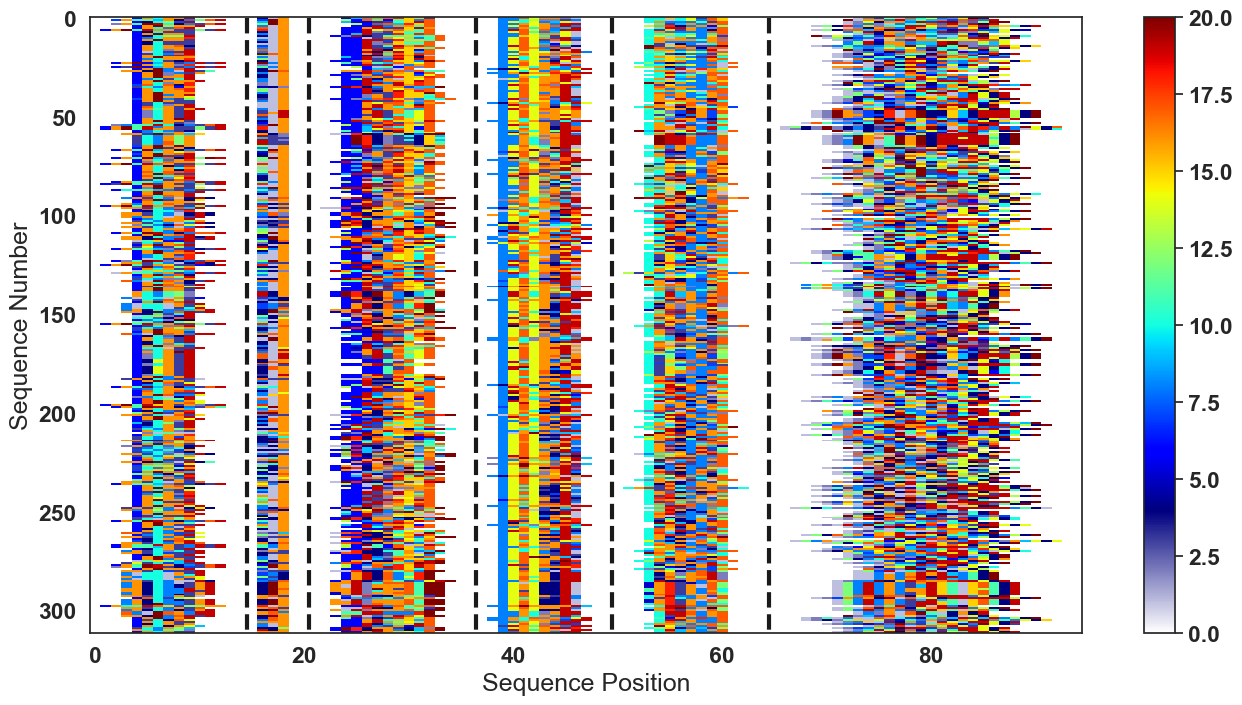

In [34]:
#################################
# The "align" option only changes alignments for Ig, not MSA encodings
align = 'center'
# This "pad" value only changes things if your alignemnt is "bulge"
# Otherwise keep it defined as 8, again another dummy variable that you need to keep
pad = 8
#################################

if molecule.lower() == 'ig':
    seq_MIpre = aims.gen_tcr_matrix(np.array(seqF),AA_key = my_AA_key,key=AA_num_key, giveSize = mat_size, alignment = align, bulge_pad=pad)
elif molecule.lower() == 'peptide':
    seq_MIpre = aims.gen_tcr_matrix(np.array(seqF),AA_key = my_AA_key,key=AA_num_key, giveSize = mat_size, alignment = align, bulge_pad=pad)
elif molecule.lower() == 'msa':
    AA_num_key_dash = np.hstack((AA_num_key,[0]))
    seq_MIpre = aims.gen_MSA_matrix(np.array(seqF),AA_key_dash = my_AA_key_dash, key = AA_num_key_dash, giveSize = mat_size)

seq_MIf = pandas.DataFrame(np.transpose(seq_MIpre),columns = seqF.columns)

fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(16,8))
x = ax[0,0].imshow(np.transpose(seq_MIf), interpolation='nearest', aspect='auto',cmap=cmap)
ax[0,0].set_ylabel('Sequence Number')

######
# It will help to have vertical dashed black lines to guide the viewer
seq1_len = np.shape(seqF)[1]
Numclones = int(seq1_len)
if type(mat_size) != int:
    for i in np.arange(len(mat_size)-1):
        ax[0,0].plot( (mat_size[i] + sum(mat_size[:i]) - 0.5) * np.ones(Numclones),np.arange(Numclones),'k--',linewidth = 3)
#######
ax[0,0].set_xlabel('Sequence Position')

pl.colorbar(x)
pl.savefig(outputDir+'/AIMS_mat.pdf',format='pdf')

# Section 2.5 Copy the Encoding Back into Sequences
- i.e. pads are represented by "-" for each sequence
- Uncomment if you want to do this, but this bit of code can be quite slow.

In [4]:
# Note: no output here, just saves file as "AIMS_encodedSeqs"
# Also Note: This code is quite slow, so don't run unless you need to
#utils.back_decode(seq_MIf,outputDir,my_AA_key,AA_num_key)

# Section 3: Calculate our Biophysical Property Matrices
The only thing that you *might* need to change in the below code is the decision to normalize the biophysical properties or not. Default is to normalize

In [4]:
##################################################################################
# Process this new matrix and apply biophysical propery "masks"
# This has to be changed from the binary case, because we aren't looking for differences
normalize = 'msuv'
dsetF = seqF.values
# Renormalize explicitly tries to make the higher entropy regions 
# more important in the matrix... 2**entropy
renormalize = True
# nCores are the number of cores to run parallel processing on
# If you don't want to run code in parallel, set to 1
# Setting to -1 uses all cores
nCores = -1
###################################################################################

# Absolutely insane number of things we need to pass through this
# function, BUT, compresses ~75 lines of code into 2
full_big,parsed_mat,NonNorm_big,IDed_full_big,seq_bigReshape,token_df = utils.grab_big(seqF,dsetF,seq_MIf,datName,normalize,renormalize,molecule,
             my_AA_key,my_AA_key_dash,mat_size,align,pad,nCores)

/Users/cboughter/miniforge3/envs/aims_dev/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cboughter/miniforge3/envs/aims_dev/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


# Section 4: Sequence Projection & Clustering

# The next few cells are particularly powerful for isolating interesting populations in the dataset using PCA, UMAP, and KMeans Clustering

This is really a section where you should take your time and toggle some of these settings. Look at your data using PCA and UMAP

Try to use "full", "parse", or "avg" biophysical properties for each entry as input into the dimensionality reduction 

The below cell is important to define, so we set it apart from the rest of the code

In [6]:
# DEFINE WHICH FORM OF THE DATASET YOU WOULD LIKE TO ANALYZE HERE
# Perform dim. red. on the whole dataset? enter "full"
# Want to do it on a dataset with highly correlated vectors removed? enter "parse"
# Lastly, can just do it on a matrix of the per-sequence average over 61 props? enter "avg"
###################################################################################
# enter "full", "parse", or "avg"
dchoice = 'parse'

# Then, choose which dimensionality reduction and clustering method you want to use
# Want to run pca or umap?
reduce = 'umap'
# What will you cluster with (kmean, optics, dbscan)?
clust = 'kmean'
###################################################################################

# The below section then uses the above information to actually calculate these things

There is a lot of opportunity to go EVEN deeper into the code here to tweak your analysis. Important to do if you really care about the data. Alter things like:
- Nclust for Kmeans
- min_samples for OPTICS
- eps for DBSCAN
- Setting random seeds for UMAP (see the ReadTheDocs for the disclaimer for using UMAP)

In [7]:
# Don't change these if statements, change the stuff below that
if dchoice.lower() == 'full':
    chosen_dset = full_big
elif dchoice.lower() == 'parse':
    chosen_dset = parsed_mat
elif dchoice.lower() == 'avg':
    chosen_dset = np.average(seq_bigReshape,axis=2)

# "state" is the umap random_state. If you set it to None, it can be parallel, but not reproducible
clust_input,cluster_dset = utils.do_cluster(chosen_dset,seq_MIf,reduce,clust,min_samples=100,eps=0.5,state=None)

/Users/cboughter/miniforge3/envs/aims_dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Section 5: Plotting Clustering and (Optional) Metadata
The previous section was just for calculating these things. We are now going to provide users with a few different options to visualize their data

By default we show 2D and 3D cluster projections with metadata and clustered data but give users control over which is shown

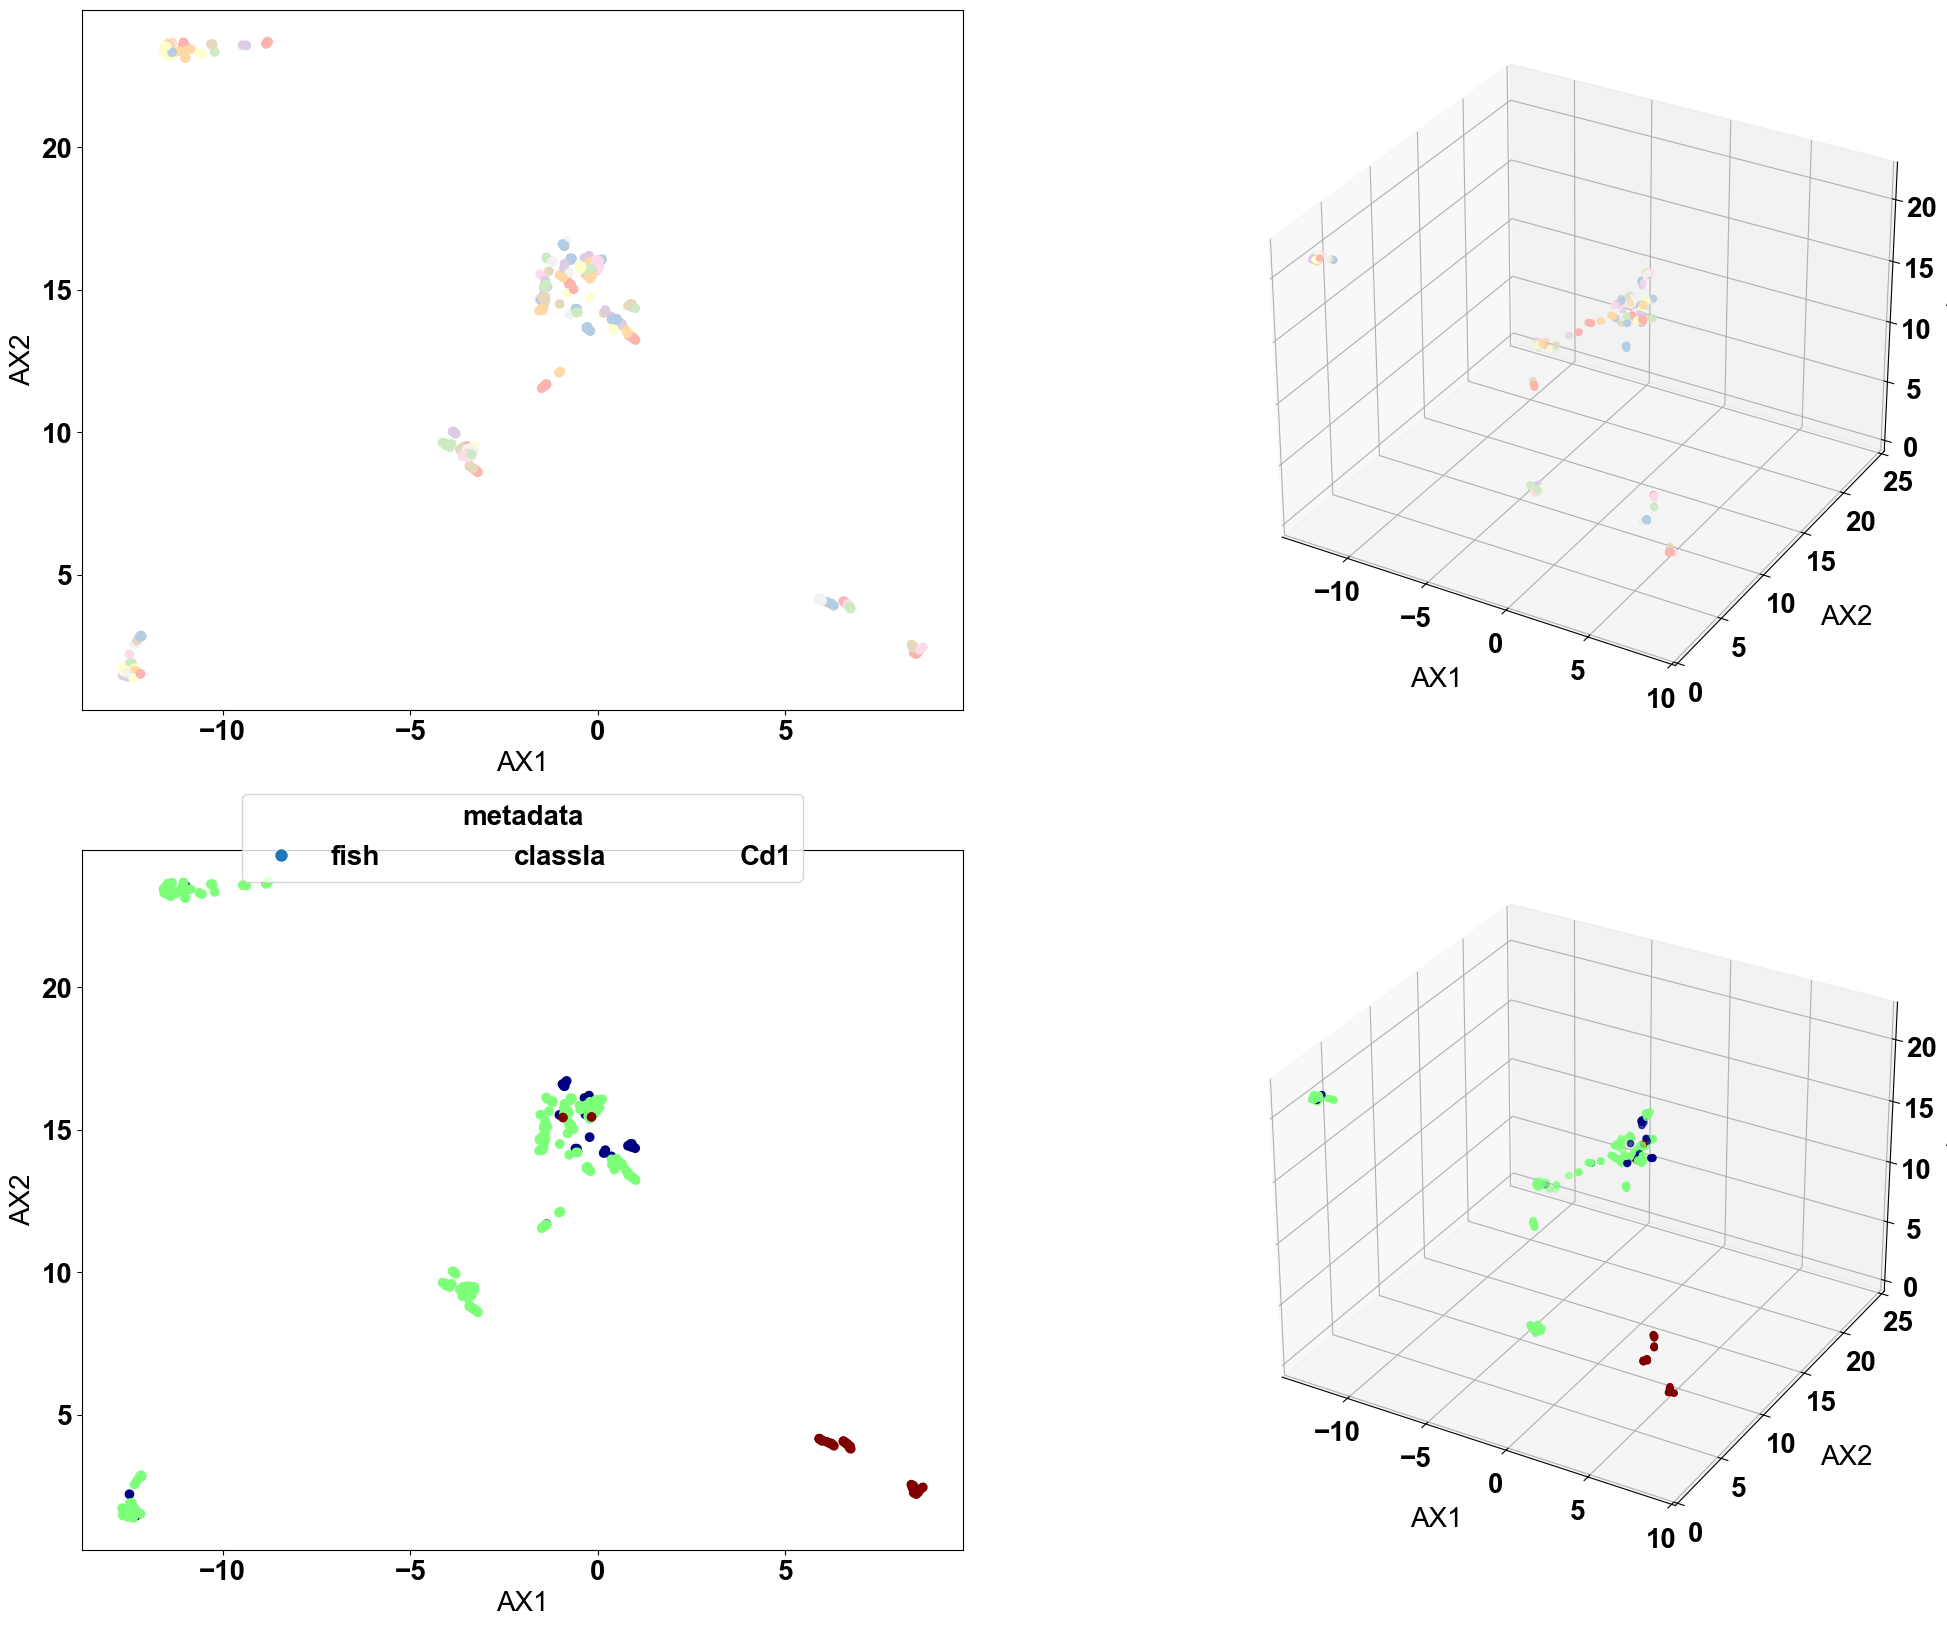

In [8]:
# All the things this function is returning
#clust_map,clust_leg,clust_name,meta_map,meta_leg,meta_name
plot_metas = utils.get_metadata(token_df,datName,cluster_dset)
fig3d,ax,keep_map =  utils.plot_clusters(clust_input,plot_metas,clust)

fig3d.canvas.draw()

#pl.savefig(outputDir+'/AIMS_projections.pdf',format='pdf')
#pl.show()

# Section 6: Quantify Cluster Compositions
This step might be meaningless if you don't have ANY metadata to go off of, and/or are not comparing/contrasting two datasets. This is fine, you should still run this step to make sure that everything is properly defined


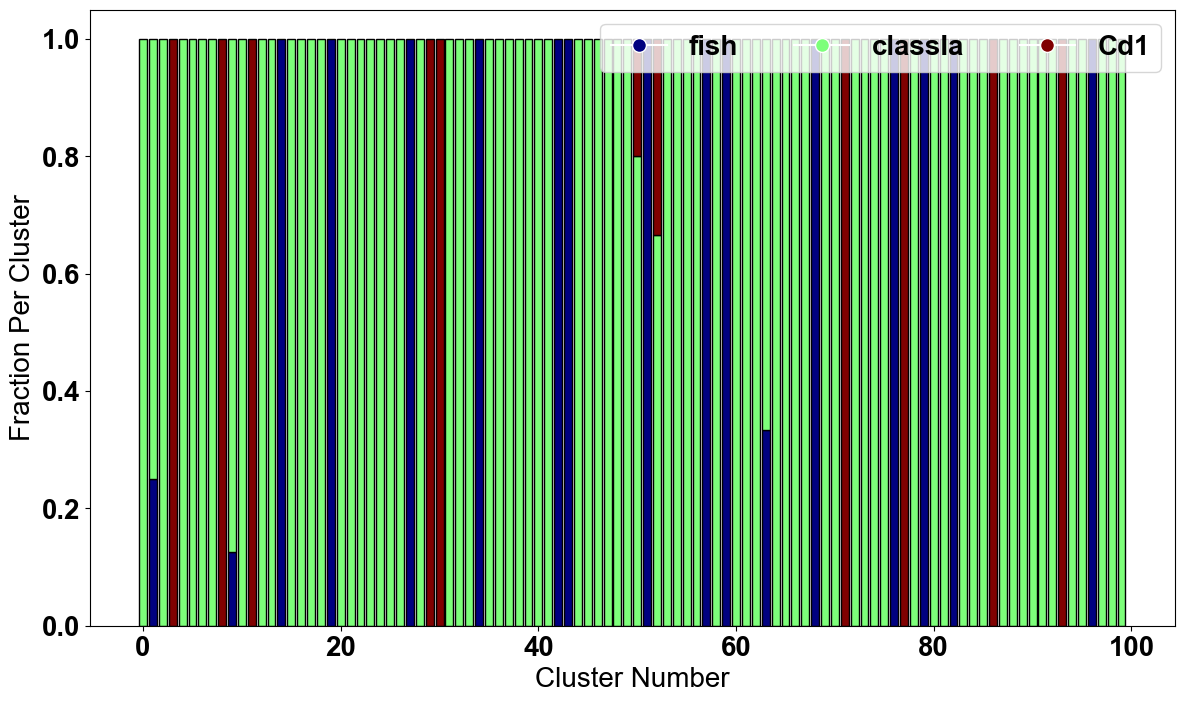

In [9]:
clust_map=plot_metas[0];clust_leg=plot_metas[1]; clust_name=plot_metas[2]; 
meta_map=plot_metas[3]; meta_leg=plot_metas[4];meta_name=plot_metas[5]
# As a note, it appears that calling the function plots it in the cell
fig,final_breakdown,meta_legF=utils.plot_quantClust(cluster_dset,keep_map,plot_metas)
pl.savefig(outputDir+'/AIMS_clusterQuant.pdf',format='pdf')

# Section 7: Calculating Cluster Purity
With new update (AIMS 0.8) we now have statistical quantifications for most outputs. However, these cluster purity calculations are somewhat slow to run. If users do not have interesting metadata, you may not want to run this step. Outputs generated here are not used elsewhere in the notebook

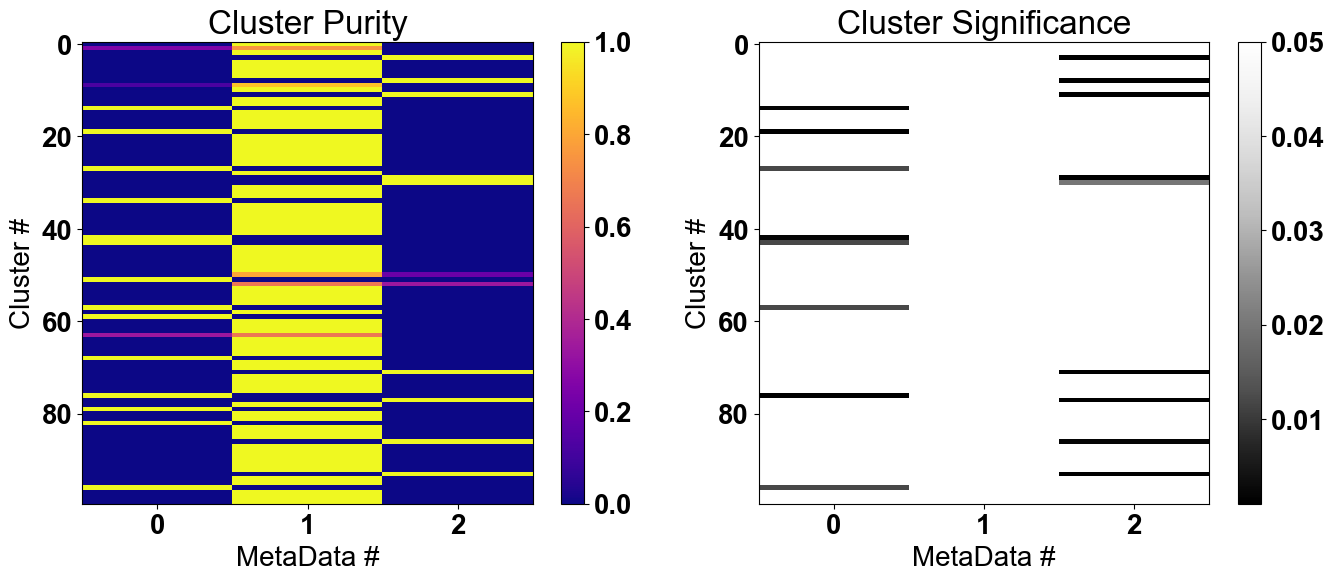

In [10]:
run_clustPure = True
if run_clustPure:
    fig, ax = pl.subplots(1, 2,squeeze=False,figsize=(16,6))

    cluster_purity,purity_pVal = aims.calc_cluster_purity(final_breakdown,meta_name)

    x = ax[0,0].imshow(cluster_purity,interpolation='nearest', aspect='auto',vmax = 1,cmap='plasma')
    y = ax[0,1].imshow(purity_pVal,interpolation='nearest', aspect='auto',vmax = 0.05,cmap='Greys_r')

    ax[0,0].set_xlabel('MetaData #'); ax[0,1].set_xlabel('MetaData #')
    ax[0,0].set_ylabel('Cluster #'); ax[0,1].set_ylabel('Cluster #')
    ax[0,0].set_title('Cluster Purity'); ax[0,1].set_title('Cluster Significance')
    pl.colorbar(x,ax=ax[0,0]); pl.colorbar(y,ax=ax[0,1])

    pl.savefig(outputDir+'/AIMS_clusterPurity.pdf',format='pdf')

# Section 8: Defining Data Subsets of Interest to Further Characterize Repertoire
VERY IMPORTANT STEP here for all downstream analysis. Define whether you want to compare/contrast clustered sequences or analyze sequences based upon the associated metadata

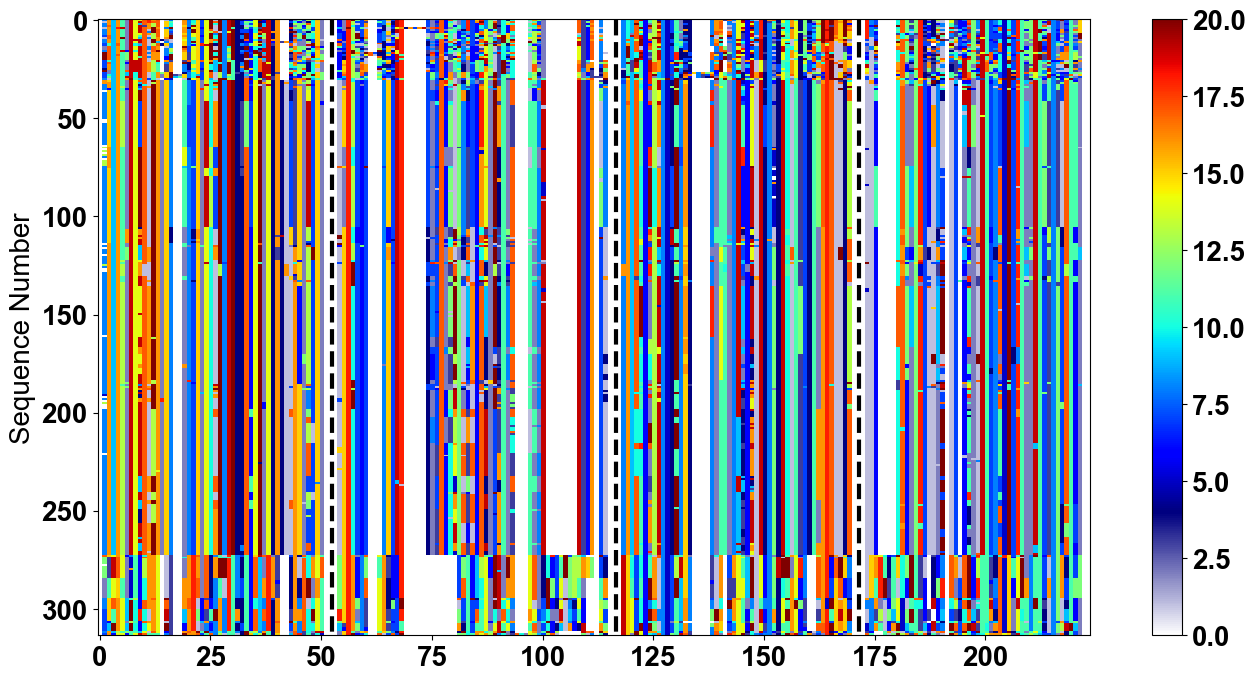

In [11]:
# Decide if you want to analyze the data by cluster or by metadata.
subset_sel = 'metadata' # other option is 'cluster'
try:
    plot_metas
except:
    print('Did not run clustering, get_metadata')
    plot_metas = utils.get_metadata(token_df,datName)

fig2,chosen_map,chosen_name = utils.plotSubsets(seq_bigReshape,seq_MIf,
                                                plot_metas,mat_size,
                                                subset_sel = subset_sel,show_lines=False)

pl.savefig(outputDir+'/AIMS_'+subset_sel+'_subViz.pdf',format='pdf')

# Can Optionally Quantitatively Assess How Biophysically Similar These Clusters Are
Borrow a page from the TCRdist software [Dash et al. Nat. Lett. 2017] from Paul Thomas' lab.

Use distance as a metric to quantify TCR similar. Our distance metric is a little different (literal Euclidean distance in AIMS-encoded space), but it correlates well with the established TCRdist metric.

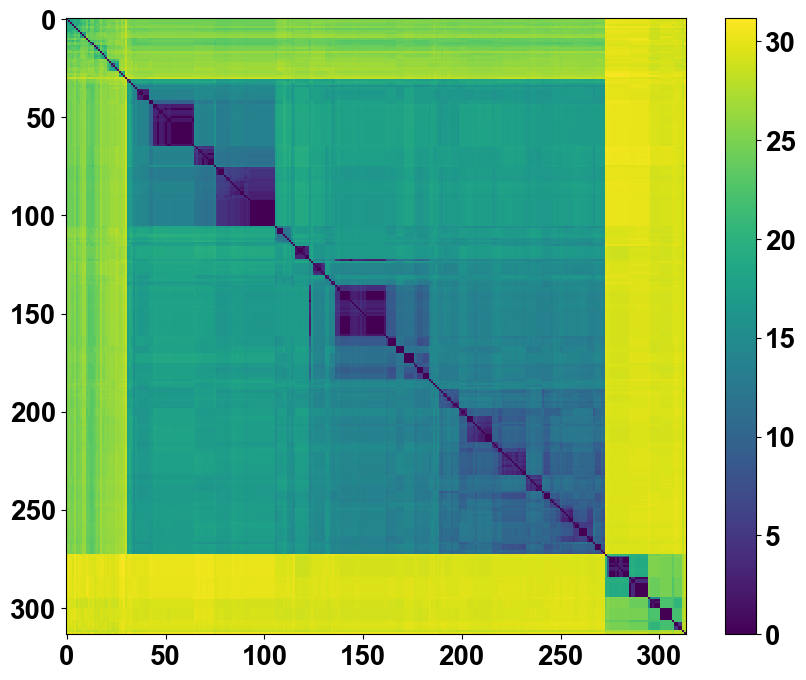

In [12]:
fig,dists,dist_clusts = utils.run_AIMSdist(NonNorm_big,seq_MIf,
                                     seqF,plot_metas,chosen_map,chosen_name)


# Section 9: Isolation of Individual Groups for Downstream Characterization
Run the next cell to visualize your clusters of choice, and then go through the remainder of the AIMS modules

Selecting the sub_sels [0,1] will select either the first two clusters or the first two metadata entries. Remember that python is 0-indexed, so if you want to look at a very specific metadata cluster then make sure you take that into account! You can *technically* visualize every cluster all at once, but that is REALLY not recommended

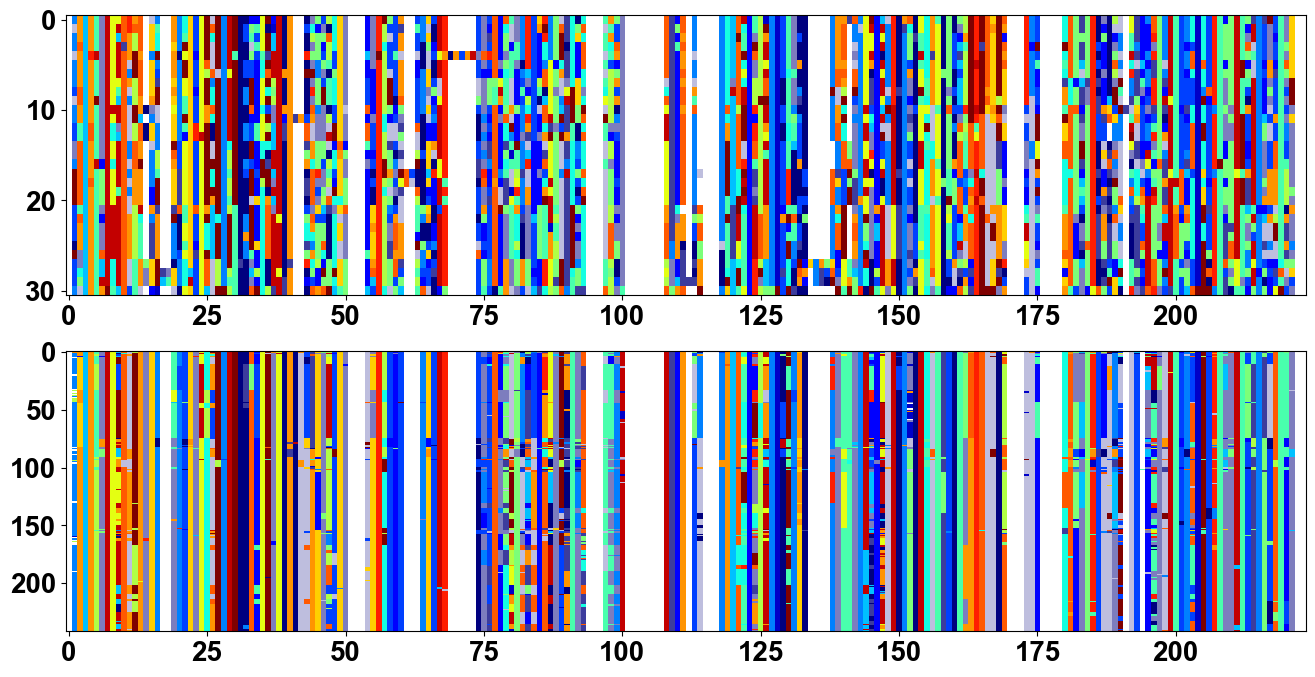

In [13]:
# So now that we've done some clustering, pick out the most interesting or sections of the data:
# You can technically pick out more than two, if desired (Assuming you have more than 2 clusters or 2 input "metadata")
sub_sels = [0,1]
try:
    meta_legF
except:
    print('Did not run clust_purity, define meta_legF')
    meta_legF = datName
#optionally output sub_seqF too with save_subSeqs=True, saveAll=True
fig,sub_matF,label,sub_seqF = utils.viz_subs(seqF,seq_MIf,meta_legF,sub_sels,chosen_map,chosen_name,save_subSeqs=True)

pl.savefig(outputDir+'/AIMS_'+subset_sel+'_selected.pdf',format='pdf')

# Leaving This Here in Case You Have Seqlogo Installed
Can be useful to visualize some sequences in this way. This code has not been tested in a while, and has not been tested at all for MSA analysis

In [14]:
%%bash
# Alright let's cheat and just use the seqlogo in bash... the python script is a little bit of a pain.
# Code is from reference: 
#Crooks GE, Hon G, Chandonia JM, Brenner SE WebLogo: A sequence logo generator, Genome Research, 14:1188-1190, (2004)

# Obviously, change this path to wherever YOUR seqlogo is and whatever your filename is
#weblogo/seqlogo -F PDF -c -n -Y -f sub1_logo.txt > sub1_logo.pdf

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


# Section 10: Generate Subsets of Matrices We Have Calculated Previously
This will save some time compared to how things were done before.

In [14]:
# define "RE" variables so we don't mess with any variables upstream (in case you want to re-run)
full_big_re = NonNorm_big; full_big_re.index = seq_MIf.columns
parsed_mat_re = parsed_mat; parsed_mat_re.index = seq_MIf.columns
# use the transpose of the sub_mat to find the 
ref_sub = np.transpose(sub_matF)
ref_sub.columns = np.arange(len(sub_matF))

sub_big = full_big_re.loc[sub_matF.columns]
sub_parsed = parsed_mat_re.loc[sub_matF.columns]
# This is coming in from 
posLen,seqLen = np.shape(seq_MIf)

# Section 11: Position Sensitive Biophysical Properties for Every Clone in the Dataset
Here, we can visualize the how similar or dissimilar the biophysical properties are for each sequence within a given repertoire.

Right now we show only the charge and the hydropathy, but you can change "prop1" in either cell to visualize a different property (see ReadTheDocs for more info)

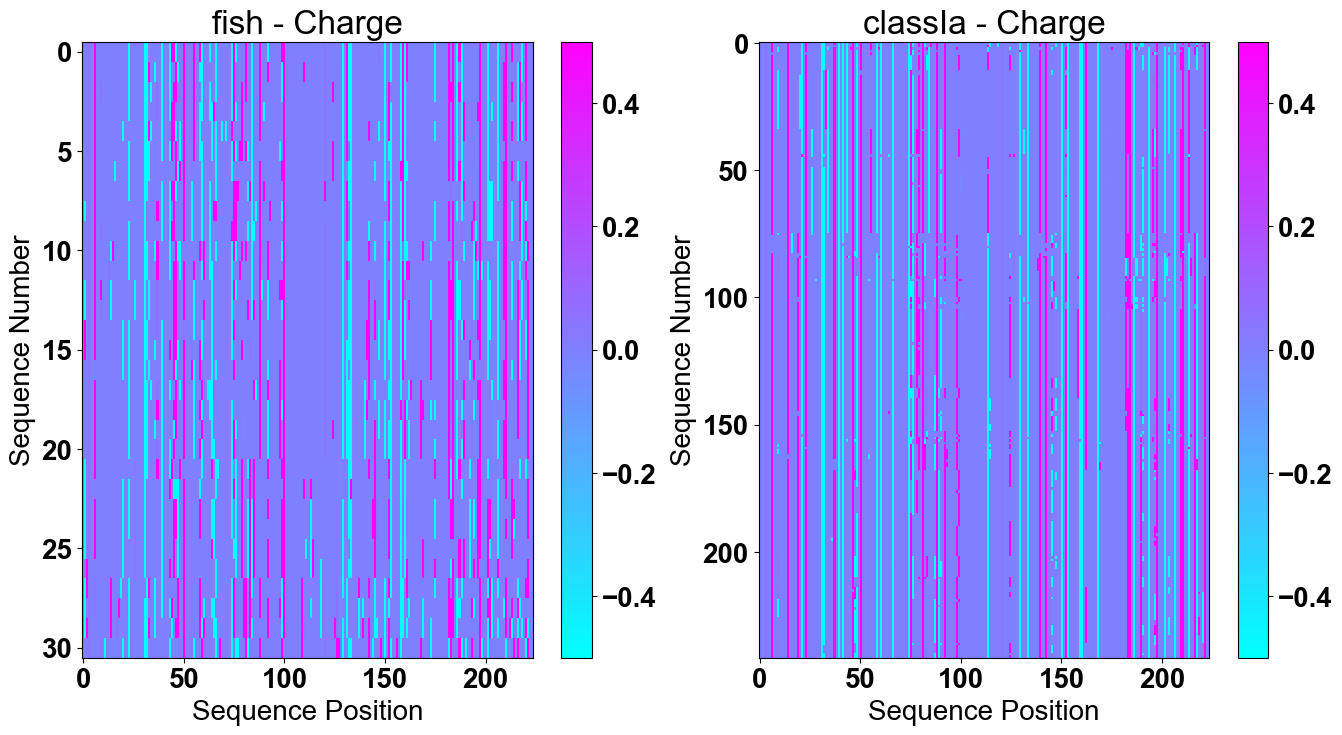

In [15]:
# Generate the position sensitive charge across all clones in the dataset
# Which property will you want to look at down the line? 1 = charge, 2 = hydrophobicity... see full list in eLife paper (Boughter et al. 2020)
prop1 = 1

fig, axs = pl.subplots(1, len(sub_sels),squeeze=False,figsize=(8*len(sub_sels),8))

for dat in np.arange(len(sub_sels)):
    take_sub = ref_sub[ref_sub[len(sub_matF)-1] == dat].index
    take_big = sub_big.loc[take_sub]
    temp_bigReshape = np.array(take_big).reshape(len(take_big),61,posLen)
    x = axs[0,dat].imshow(temp_bigReshape[:,prop1,:],interpolation='nearest', aspect='auto',cmap=cm.cool, vmin = -0.5, vmax = 0.5)
    axs[0,dat].set_xlabel('Sequence Position'); axs[0,dat].set_ylabel('Sequence Number')
    axs[0,dat].set_title(str(label[dat]) + ' - Charge')
    fig.colorbar(x, ax=axs[0,dat])

pl.savefig(outputDir+'/AIMS_'+subset_sel+'_charge.pdf',format='pdf')

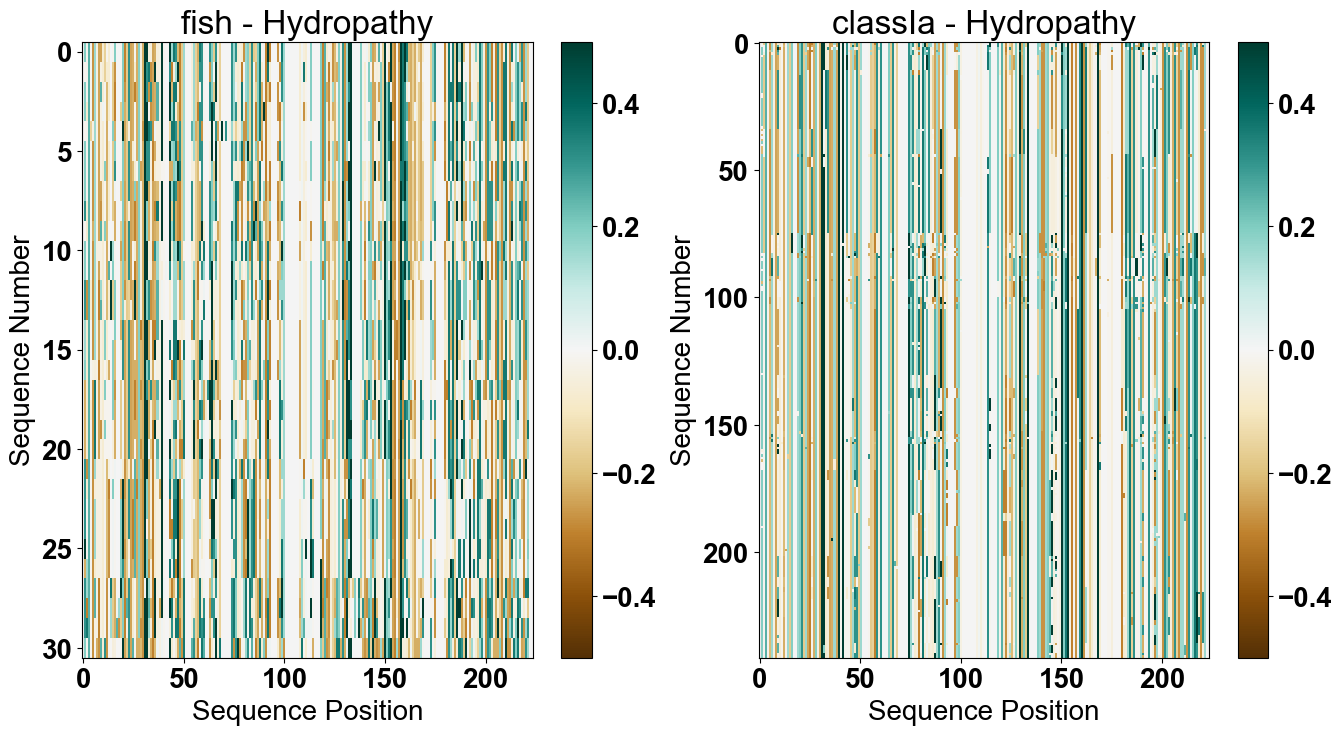

In [16]:
# Do the same thing again for hydropathy
prop1 = 2
fig, axs = pl.subplots(1, len(sub_sels),squeeze=False,figsize=(8*len(sub_sels),8))

for dat in np.arange(len(sub_sels)):
    take_sub = ref_sub[ref_sub[len(sub_matF)-1] == dat].index
    take_big = sub_big.loc[take_sub]
    temp_bigReshape = np.array(take_big).reshape(len(take_big),61,posLen)
    x = axs[0,dat].imshow(temp_bigReshape[:,prop1,:],interpolation='nearest', aspect='auto',cmap=cm.BrBG, vmin = -0.5, vmax = 0.5)
    axs[0,dat].set_xlabel('Sequence Position'); axs[0,dat].set_ylabel('Sequence Number')
    axs[0,dat].set_title(str(label[dat]) + ' - Hydropathy')
    fig.colorbar(x, ax=axs[0,dat])

pl.savefig(outputDir+'/AIMS_'+subset_sel+'_hydropathy.pdf',format='pdf')

# Section 12: Averaged Biophysical Properties for Each Group of Interest
Look at biophysical properties averaged over clones AND position

Note for old users of the software, you might get different looking results because originally I normalized vectors to unit length, but NOT 0 mean. I now do both.

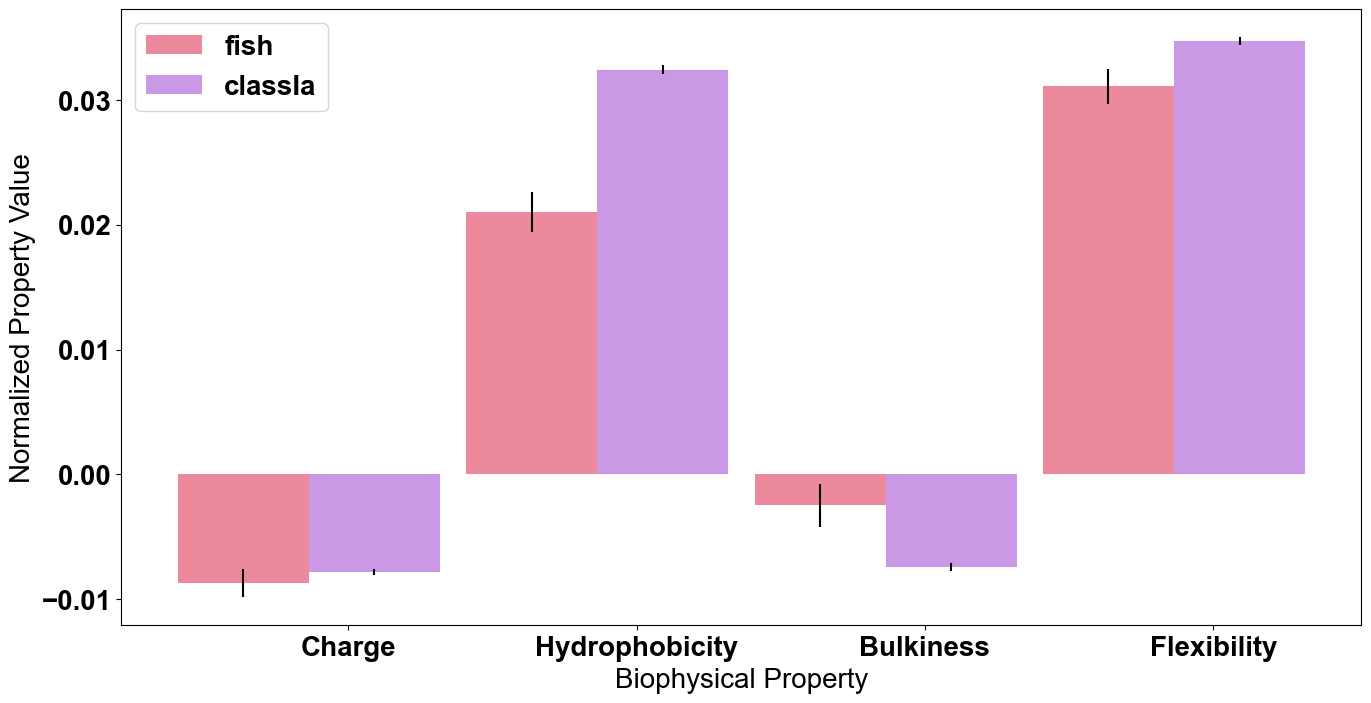

In [17]:
fig = utils.do_netAvg(sub_big,ref_sub,sub_matF,sub_sels,posLen,label,bootstrap=True,boots=1000)
       
pl.savefig(outputDir+'/AIMS_'+subset_sel+'_netAvgProp.pdf',format='pdf')

# Section 13: Position-Sensitive Averaged Biophysical Properties
Here we effectively average the figures from section 11 over the y-axes, giving a general idea of trends in the biophysical properties of within-group sequences

NOTE: This figure frequently looks chaotic/hard to parse for MSA analysis. More useful for Ig analysis

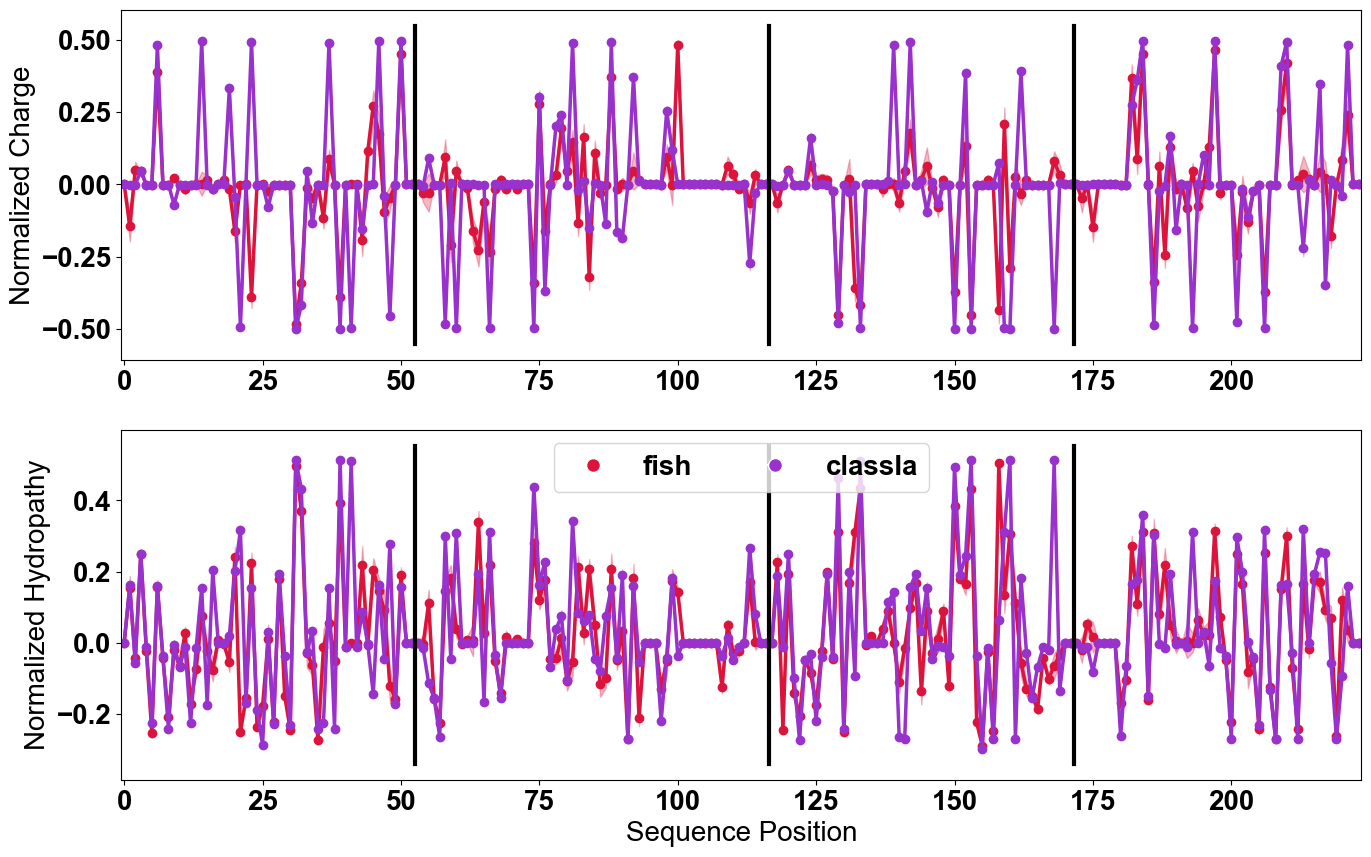

In [18]:
utils.do_posAvg(sub_sels,ref_sub,sub_matF,sub_big,posLen,mat_size,label,bootstrap=True,boots=1000)
pl.savefig(outputDir+'/AIMS_posSensAvg.pdf',format='pdf')

# Section 13.1 Calculating Statistical Significance for Position-Sensitive Metrics
Again, this is a pretty fast calculation relatively speaking. Because we're testing each individual point, it is much easier to plot the results as a figure rather than printing the p-values. The red line below gives "significance" at p<0.05

Note, reviewers have pointed out that there should perhaps be some multiple-test correction here. That's a bit tricky to implement, because should we really count those padded-zero entries as true "tests"? Probably not... There is a multiple testing function but not yet automated to output as a plot. Working on it

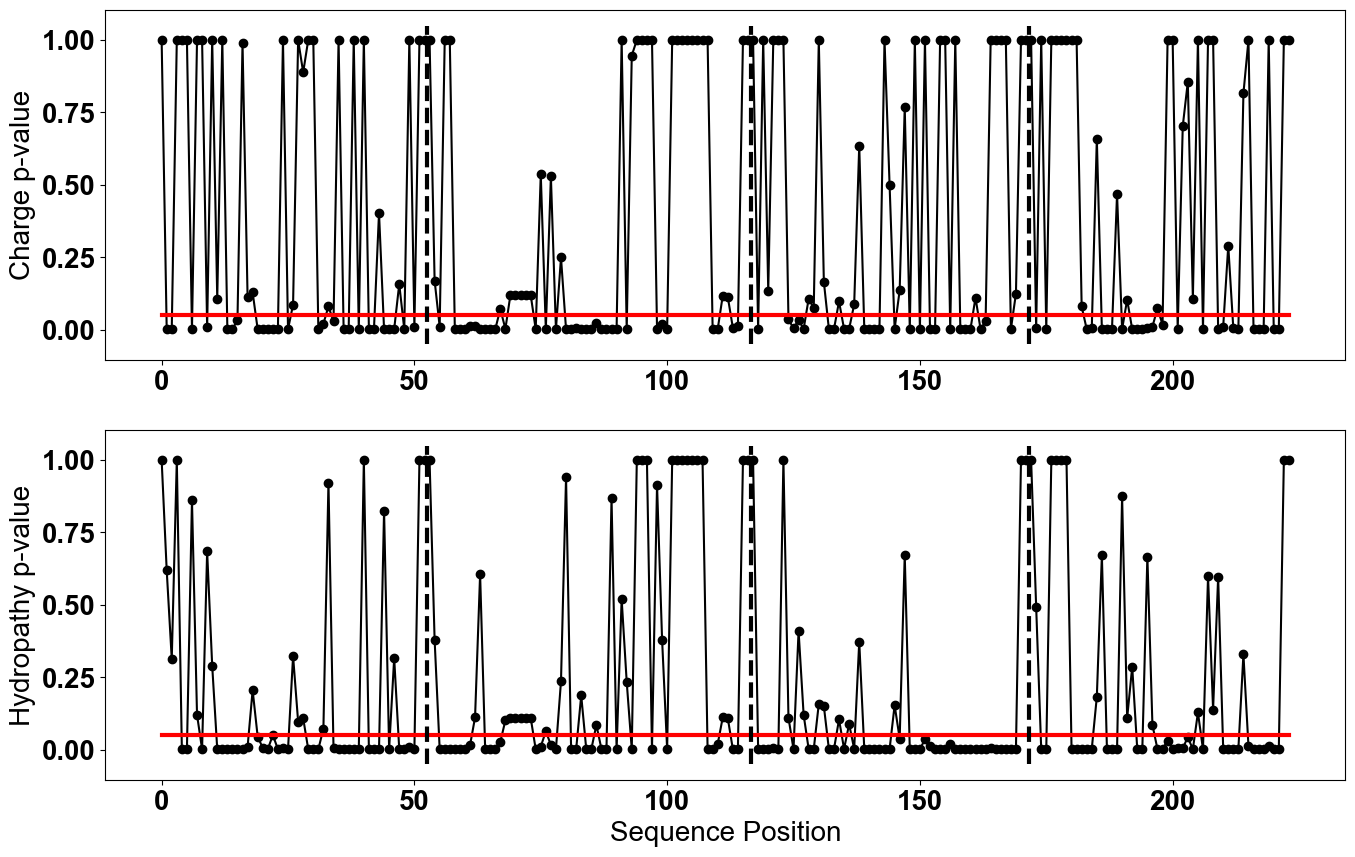

In [19]:
utils.posAvg_stats(ref_sub,sub_matF,sub_big,mat_size,posLen)
pl.savefig(outputDir+'/AIMS_PosSens_pval.pdf',format='pdf')

# Section 14: Information Theoretic Calculations
Use the Shannon Entropy and Mutual Information to quantify the diversity and inter-relations between the amino acids used in each sequence within a group
NOTE: These metrics are more useful for large datasets, less so far small datasets from DBSCAN or OPTICS identified clustered
Also NOTE: Again, these plots can be a bit hard to interpret for longer MSA sequences. Just too many points to read.
Last NOTE: Running the bootstrapping here is a bit slow. Potentially set bootstrap to False if in exploratory mode

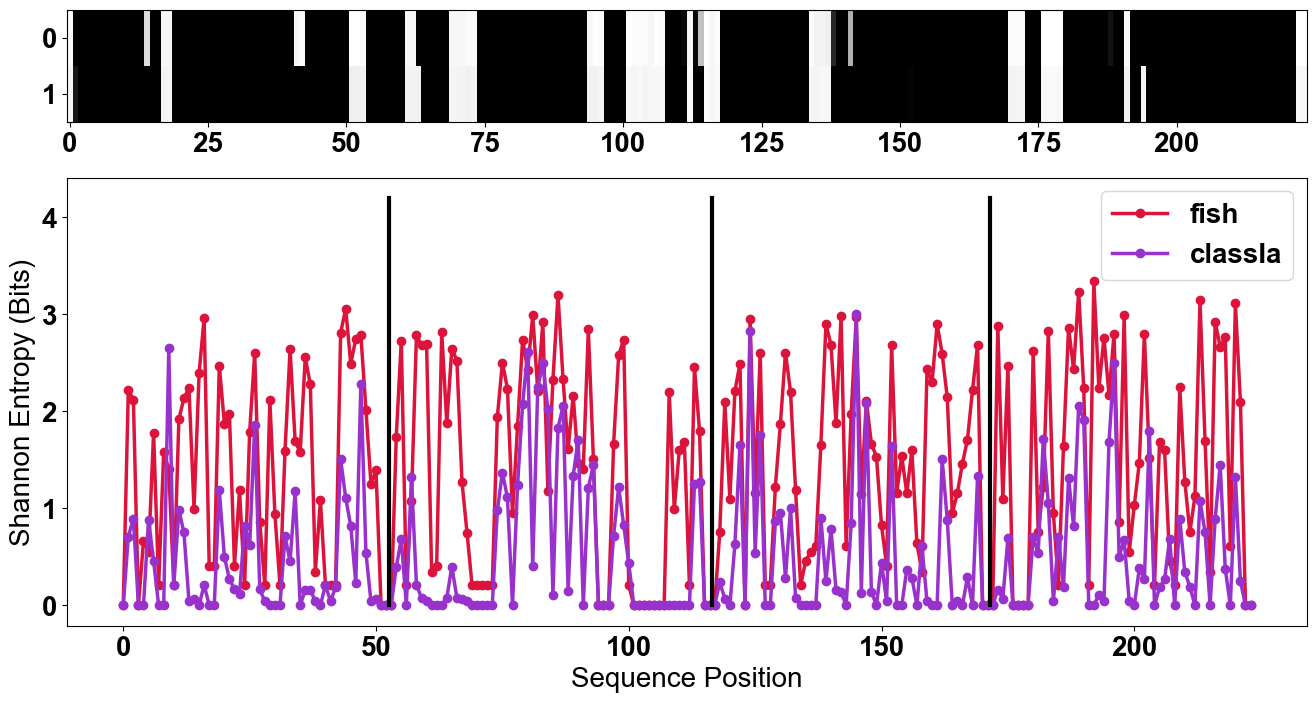

In [20]:
# Calculate the Shannon Entropy, a proxy for diversity
fig,entropy,frequencies = utils.pos_Shannon(seq_MIf,sub_sels,sub_matF,ref_sub,mat_size,label)

pl.savefig(outputDir+'/AIMS_entropy.pdf',format='pdf')

# Section 14.1 Statistical Significance of Entropy Calculations
Similar to the position-sensitive biophysical property statistical significance above

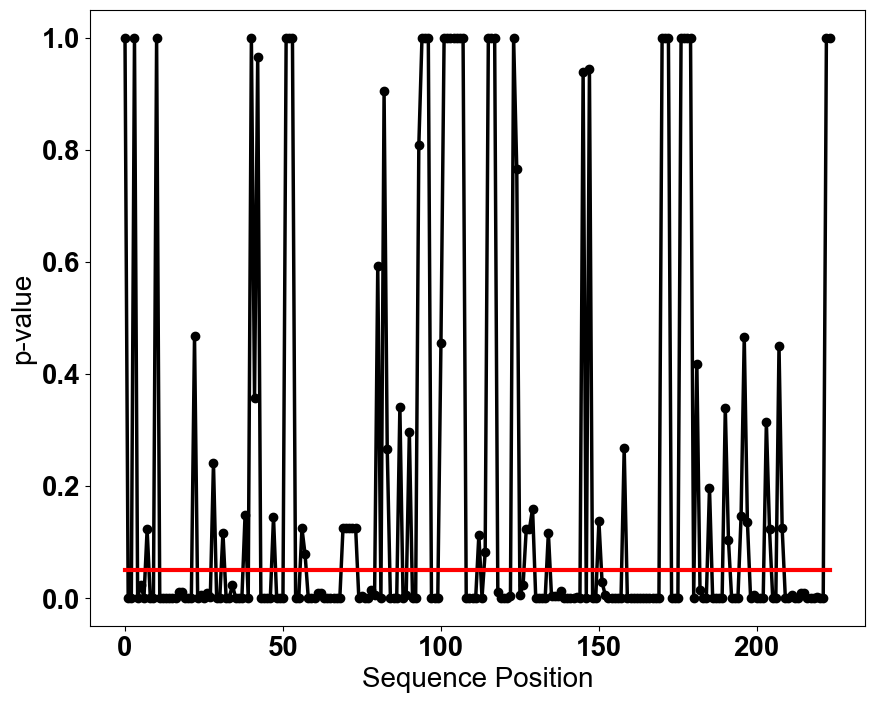

In [21]:
data1 = sub_matF[ref_sub[ref_sub[len(sub_matF)-1] == 0].index].iloc[0:-1]
data2 = sub_matF[ref_sub[ref_sub[len(sub_matF)-1] == 1].index].iloc[0:-1]
p_ent = aims.do_statistics(data1,data2,num_reps=1000,test='function',test_func=aims.calculate_shannon,func_val = 0)

fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(10,8))
pl.plot(p_ent,color='black',marker='o',linewidth=2.5)
pl.plot(np.arange(len(p_ent)),np.ones(len(p_ent))*0.05,color='red',linewidth=3)

pl.xlabel('Sequence Position')
pl.ylabel('p-value')

pl.savefig(outputDir+'/aims_entropy_pval.pdf',format='pdf')

# Section 14.2 Mutual Information Calculations

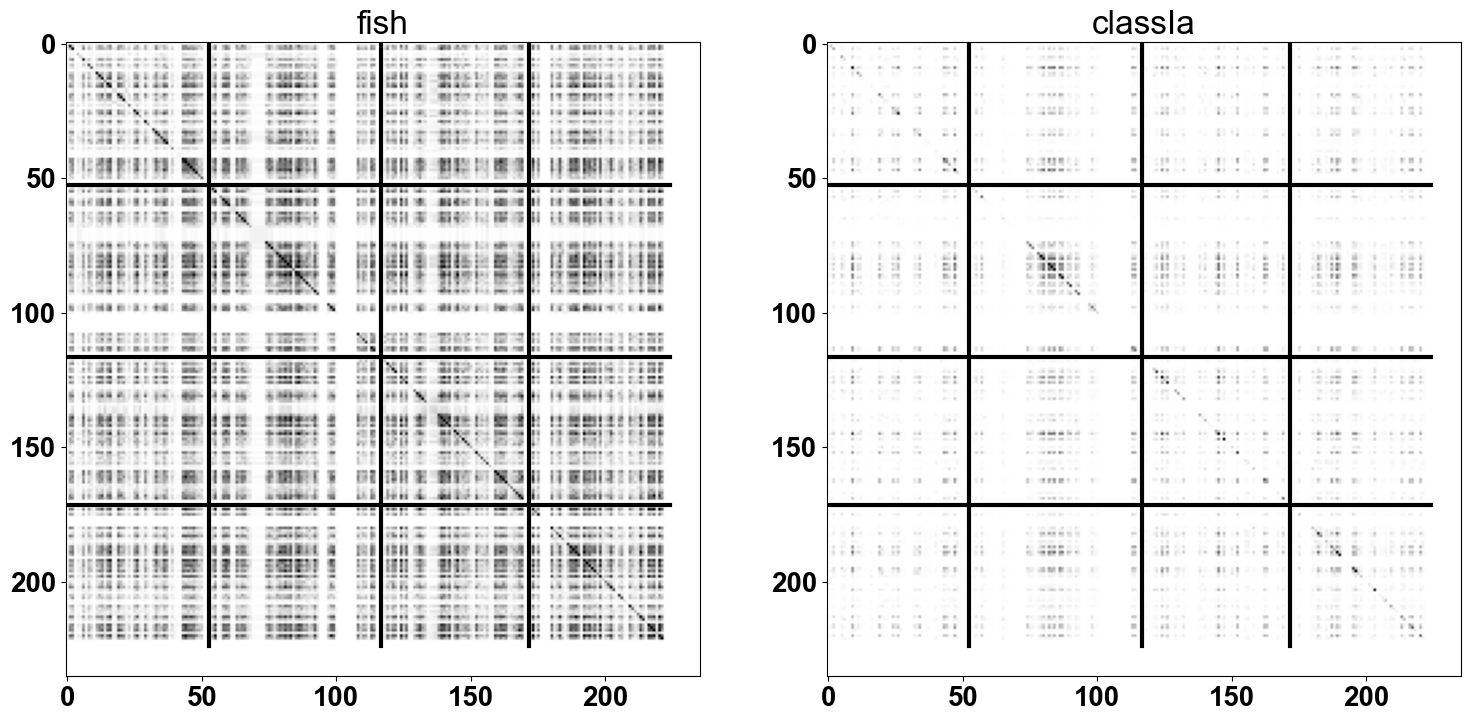

In [22]:
# And then the mutual information:
fig,MI,ent_cond = utils.pos_MI(seq_MIf,sub_sels,sub_matF,ref_sub,label,mat_size)
pl.savefig(outputDir+'/AIMS_MI.pdf',format='pdf')

# Section 14.3 Position-Sensitive Amino Acid Frequencies

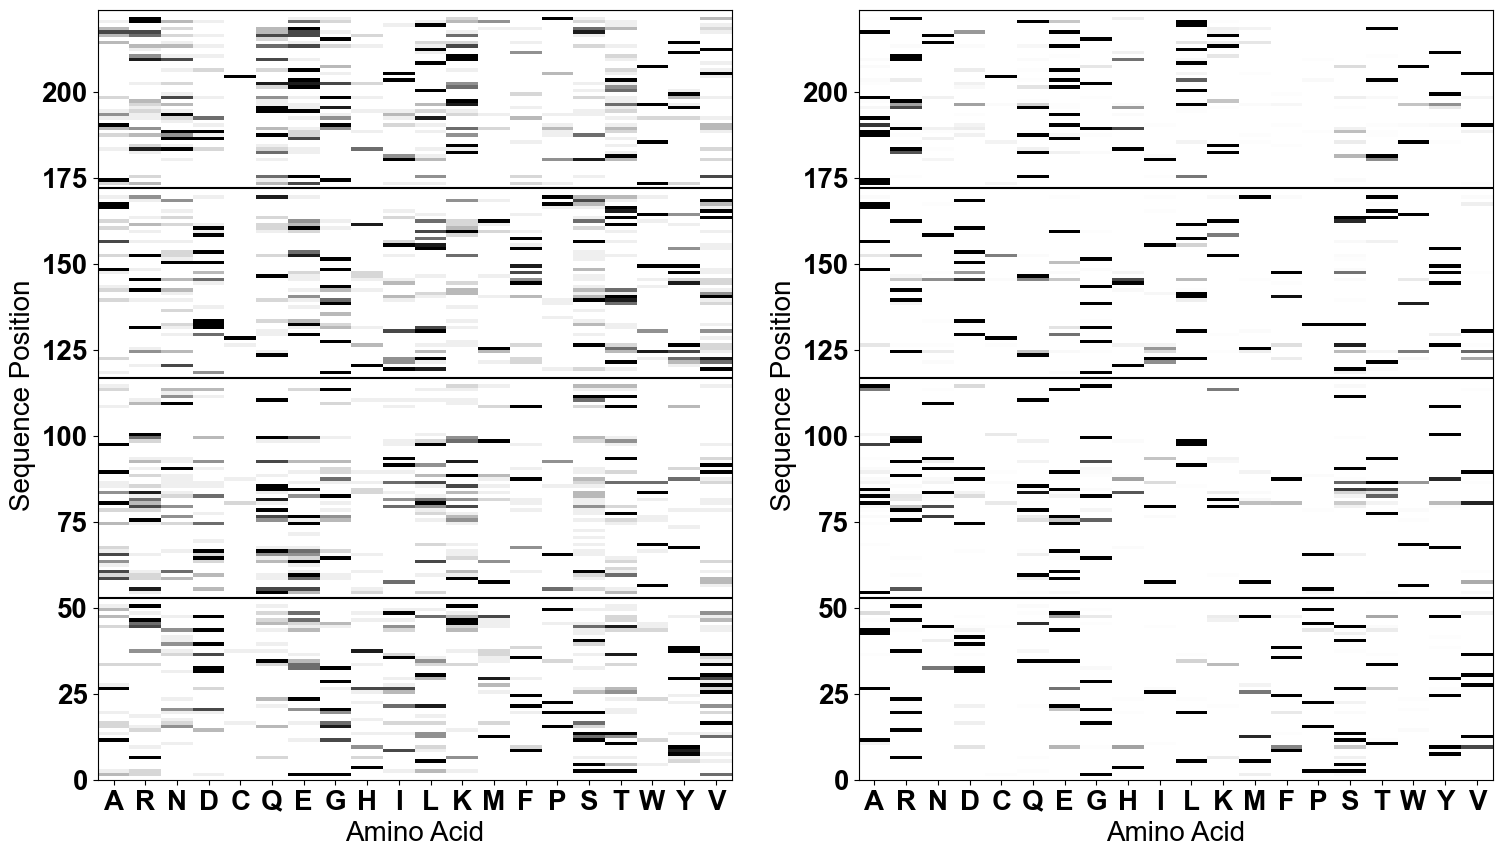

In [23]:
fig,freq1,freq2 = utils.pos_freq(frequencies,my_AA_key,mat_size)
pl.savefig(outputDir+'/AIMS_freq_sides.pdf',format='pdf')

# Section 15: Binary Comparisons Between Datasets
Anything from here on requires a comparison between only two datasets. This can be two clusters, two loaded in files, two metadata subsets, whatever.

You can continue on from the previous sections even if you were analyzing multiple datasets. The analysis will just, by default, compare only the first two datasets

# Section 15.1: Mutual Information Difference

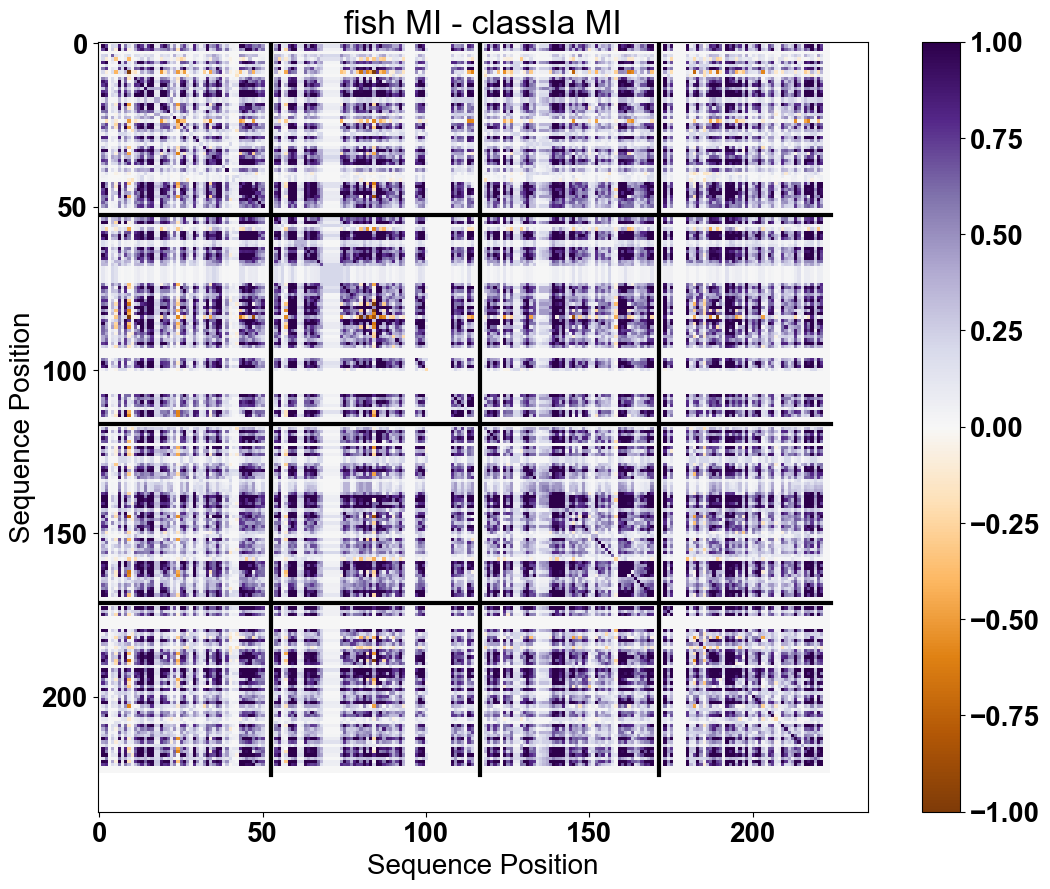

In [24]:
# A bit easier to look at the DIFFERENCE in mutual information:
fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(14,10))
x = pl.imshow(MI[0] - MI[1], cmap=cm.PuOr, vmin = -1, vmax = 1)
pl.colorbar(x); pl.title(str(label[0])+ ' MI - ' + str(label[1]) + ' MI')

# Help Guide the eyes a bit
if type(mat_size) != int:
    for i in np.arange(len(mat_size)-1):
        ax[0,0].plot((mat_size[i] + sum(mat_size[:i]) - 0.5) * np.ones(100),np.linspace(0,len(seq_MIf),100),'black',linewidth = 3)
        ax[0,0].plot( np.linspace(0,posLen,100), (mat_size[i] + sum(mat_size[:i]) - 0.5) * np.ones(100) ,'black',linewidth = 3)

pl.xlabel('Sequence Position'); pl.ylabel('Sequence Position')
pl.savefig(outputDir+'/AIMS_MIdiff.pdf',format='pdf')

# Section 15.2 Mutual Information Statistical Significance

# Num_reps is set to 10 by default, but this is almost certainly not enough permutations in any application
- Set much higher if you want to run actual stats but warning: it will be slow

Note: we again change the way we represent statistical significance for easier interpretation. Rather than show every p-value in the matrix, which can be hard to read, set a binary threshold alpha and only visualize those points with p < alpha

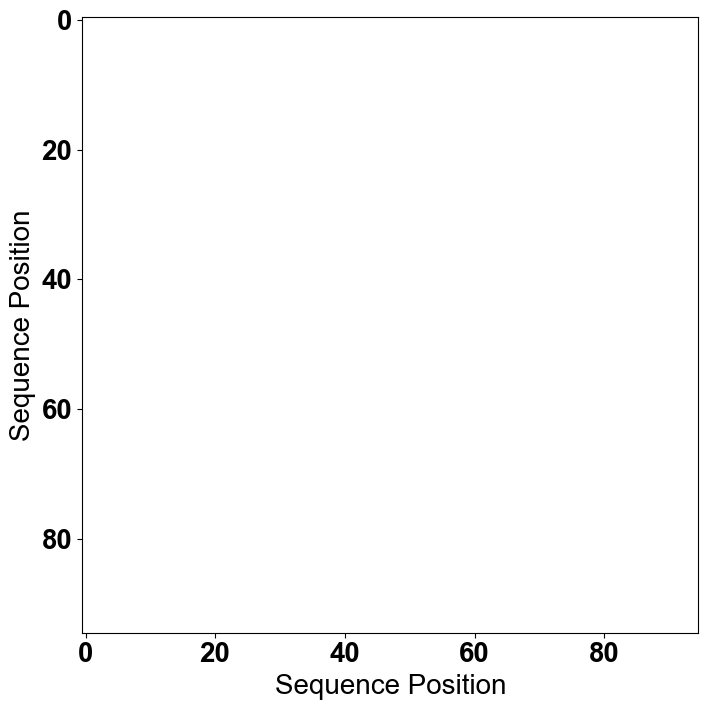

In [26]:
data1 = sub_matF[ref_sub[ref_sub[len(sub_matF)-1] == 0].index].iloc[0:-1]
data2 = sub_matF[ref_sub[ref_sub[len(sub_matF)-1] == 1].index].iloc[0:-1]
p_MI = aims.do_statistics(data1,data2,num_reps=10,test='function',test_func=aims.calculate_MI,func_val = 0)

dim1, dim2 = np.shape(p_MI)
alpha = 0.05

empty_mat_mi = np.zeros((dim1,dim2))
for a in np.arange(dim1):
    for b in np.arange(dim2):
        if p_MI[a,b] < alpha:
            empty_mat_mi[a,b] = 1

fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(10,8))

x= pl.imshow(empty_mat_mi,cmap=cm.Greys)
pl.xlabel('Sequence Position')
pl.ylabel('Sequence Position')

pl.savefig(outputDir+'/AIMS_MIdiff_sig.pdf',format='pdf')

# Section 15.3: Position-Sensitive Amino Acid Frequency Difference

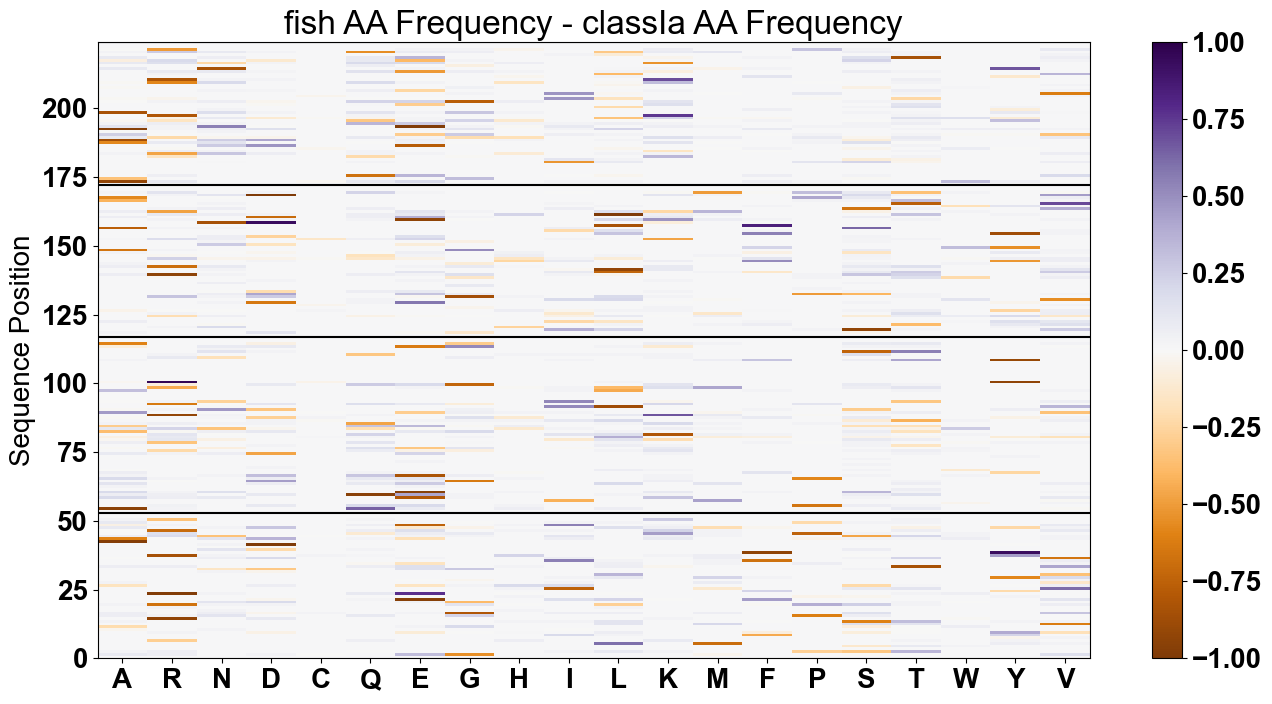

In [25]:
# Calculate the probabilities of seeing each amino acid at each position
fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(16,8))
pl.title(str(label[0])+ ' AA Frequency - ' + str(label[1]) + ' AA Frequency')
freqMax = np.max(freq1.values-freq2.values); freqMin = np.min(freq1.values-freq2.values)
freqBound = max(abs(freqMax),abs(freqMin))
fin_key = my_AA_key
x=ax[0,0].pcolormesh(freq1-freq2,vmin=-freqBound,vmax=freqBound,cmap=cm.PuOr)
AA_key=['A','R','N','D','C','Q','E','G','H','I','L','K','M','F','P','S','T','W','Y','V']
pl.colorbar(x); pl.ylabel('Sequence Position')
xax=pl.setp(ax,xticks=np.arange(20)+0.5,xticklabels=fin_key)

place=0
if type(mat_size) == int:
    pl.plot(np.arange(21),place*np.ones(21),'black')
else:
    for i in mat_size:
        place += i
        pl.plot(np.arange(21),place*np.ones(21),'black')

pl.savefig(outputDir+'/AIMS_freqDiff.pdf',format='pdf')

# Section 15.4 Position-Sensitive Amino Acid Frequency Difference Statistical Significance

Note, we again change the way we represent statistical significance for easier interpretation. Rather than show every p-value in the matrix, which can be hard to read, set a binary threshold alpha and only visualize those points with p < alpha

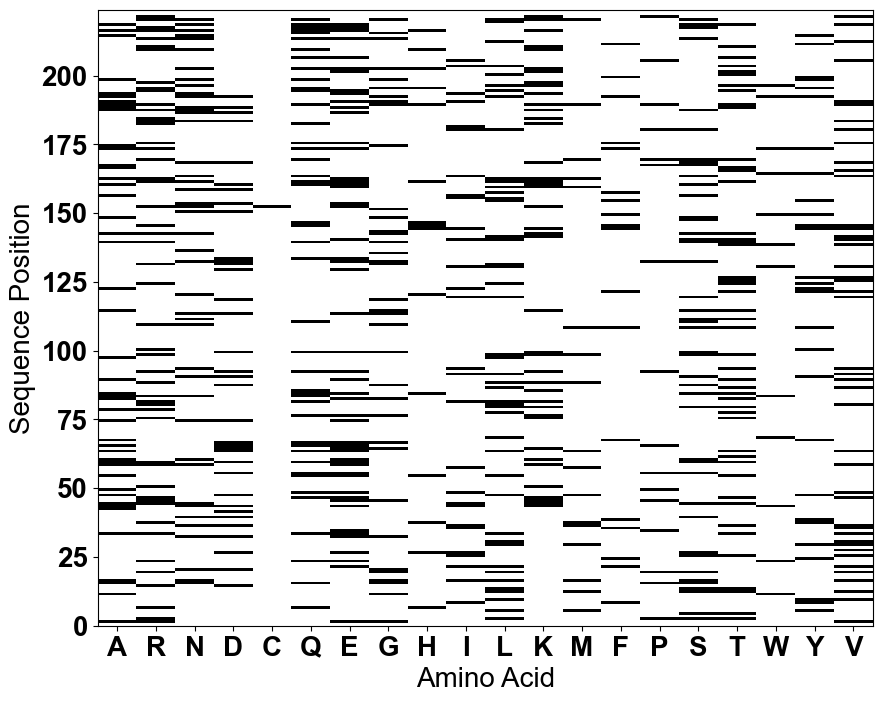

In [26]:
data1 = sub_matF[ref_sub[ref_sub[len(sub_matF)-1] == 0].index].iloc[0:-1]
data2 = sub_matF[ref_sub[ref_sub[len(sub_matF)-1] == 1].index].iloc[0:-1]
p_freq = aims.do_statistics(data1,data2,num_reps=1000,test='function',test_func=aims.calculate_shannon,func_val = 1)

dim1, dim2 = np.shape(p_freq)
alpha = 0.05

AA_key=['A','R','N','D','C','Q','E','G','H','I','L','K','M','F','P','S','T','W','Y','V']

empty_mat = np.zeros((dim1,dim2))
for a in np.arange(dim1):
    for b in np.arange(dim2):
        if p_freq[a,b] < alpha:
            empty_mat[a,b] = 1

# Need stuff to optionally shift around the x-axis:
empty_frame = pandas.DataFrame(empty_mat[:,1:])
empty_frame.columns = my_AA_key


fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(10,8))
x = pl.pcolormesh(empty_frame,cmap=cm.Greys)
xax=pl.setp(ax,xticks=np.arange(20)+0.5,xticklabels=fin_key)
pl.ylabel('Sequence Position')
pl.xlabel('Amino Acid')
pl.savefig(outputDir+'/aa_diff_statSig.pdf',format='pdf')

# Section 16: Linear Discriminant Analysis

/Users/cboughter/miniforge3/envs/aims_dev/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cboughter/miniforge3/envs/aims_dev/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Classification Accuracy
1.0


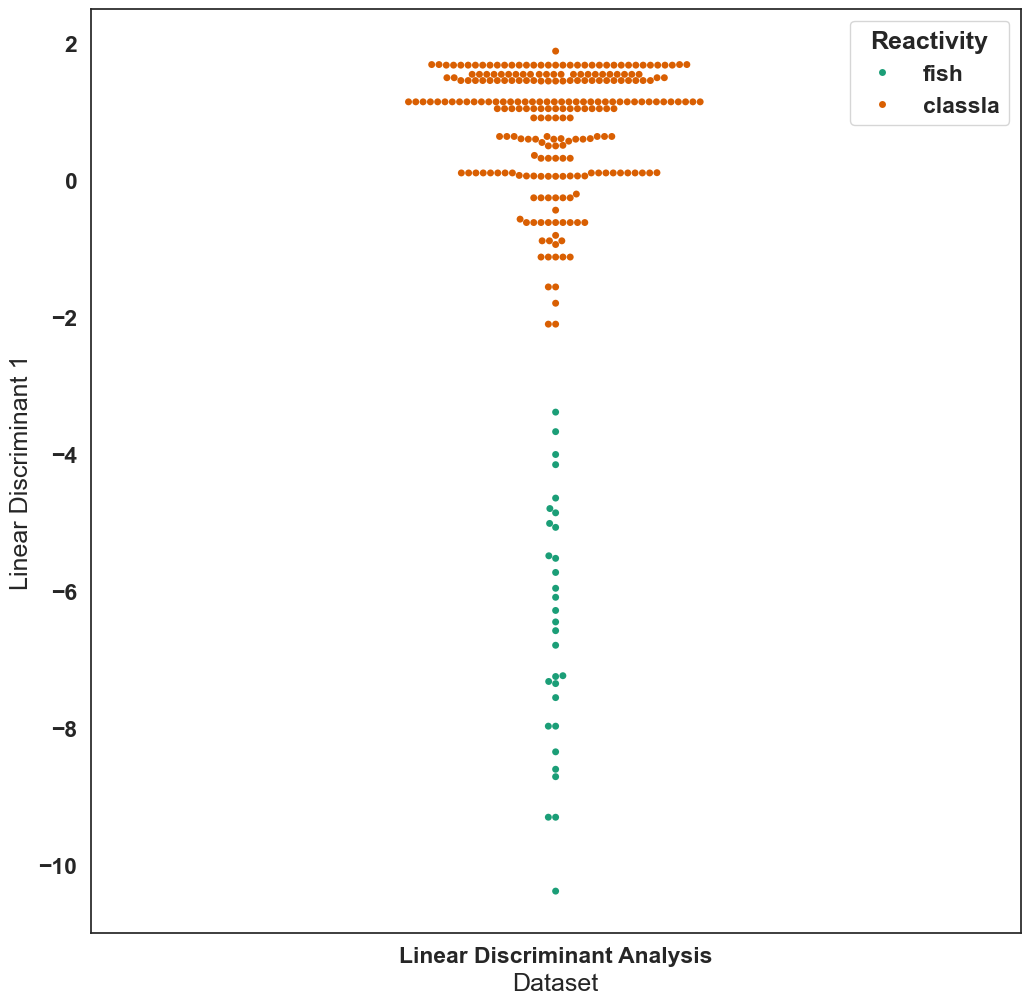

In [27]:
bigass1 = full_big_re.loc[ref_sub[ref_sub[len(sub_matF)-1] == 0].index]
seq1_len = len(bigass1)
bigass1.index = np.arange(seq1_len)
bigass2 = full_big_re.loc[ref_sub[ref_sub[len(sub_matF)-1] == 1].index]
seq2_len = len(bigass2)
bigass2.index = np.arange(seq2_len)

######### Run the actual classification here ###############
# Change the matSize variable to alter the number of vectors used to generate a classification
bigF,weights,acc_all,mda_all,final,top_names = classy.do_linear_split(bigass1,bigass2,got_big=True,matSize=10)
############################################################

import seaborn as sns
fig = pl.figure(figsize = (12, 12))
dset = ["Linear Discriminant Analysis" for x in range(seq1_len+seq2_len)]
reacts = [label[0] for x in range(seq1_len)] + [label[1] for x in range(seq2_len)]

d1 = {'Dataset': dset, 'Linear Discriminant 1': mda_all.reshape(len(mda_all)),
    'Reactivity' : reacts}
df1 = pandas.DataFrame(data=d1)
sns.set(style="white", color_codes=True,font_scale=1.5)
sns.swarmplot(x="Dataset", y="Linear Discriminant 1", data=df1, hue = 'Reactivity', palette = "Dark2")
print("Classification Accuracy")
print(acc_all)
pl.savefig(outputDir+'/AIMS_LDA.pdf',format='pdf')

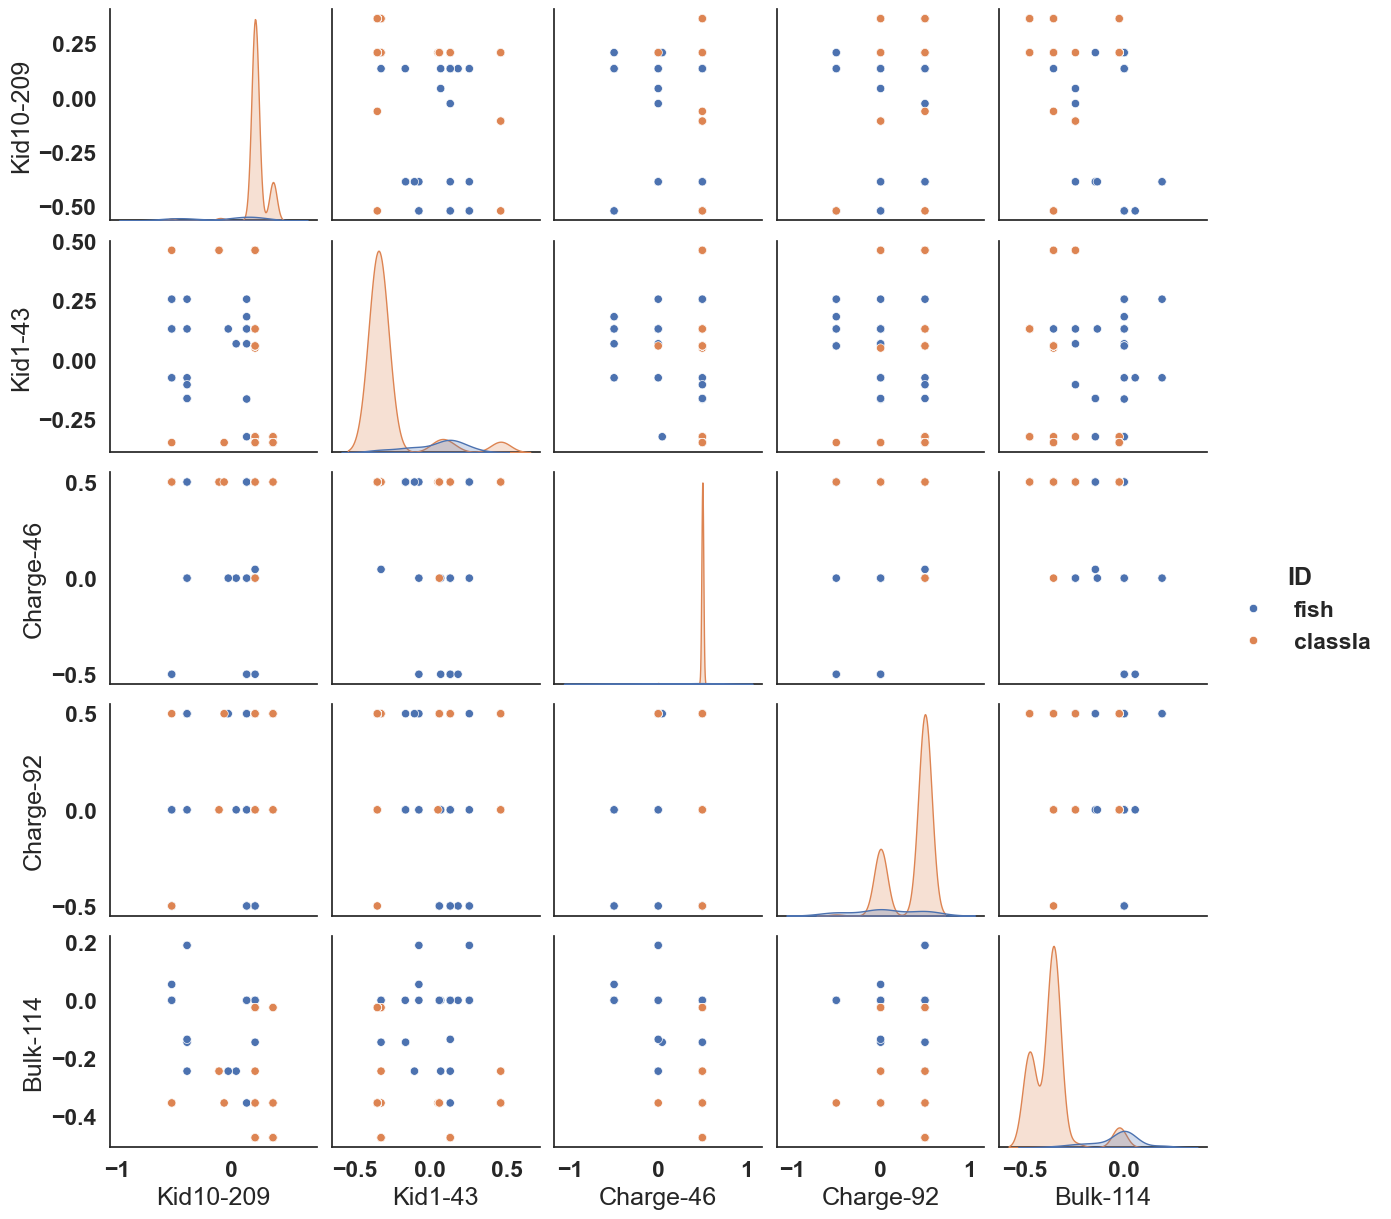

In [28]:
# Show the top properties that differentiate the two populations
# show_top = how many of these top values do you want to show? don't recommend more than ~5
# solely due to how busy the figure gets
# Again, see eLife paper for biophysical property definitions
import seaborn as sns
show_top = 5
dset_parse = final[top_names[0:show_top]]
dset_ID_pre1 = bigF['ID']
dset_ID_pre2 = dset_ID_pre1.replace(1.0,label[0])
dset_ID = dset_ID_pre2.replace(2.0,label[1])

bigass_parse_dset = pandas.concat([dset_parse,dset_ID],axis = 1)
sns.pairplot(bigass_parse_dset,hue = 'ID')
pl.savefig(outputDir+'/AIMS_pairplot.pdf',format='pdf')

# Section 17: Detailed Amino Acid Frequency Breakdowns
This feature is most useful in peptide analysis, but could be useful for general repertoire comparisons

# Section 17.1: Amino Acid Frequency

Different from the frequency before because this is position-independent

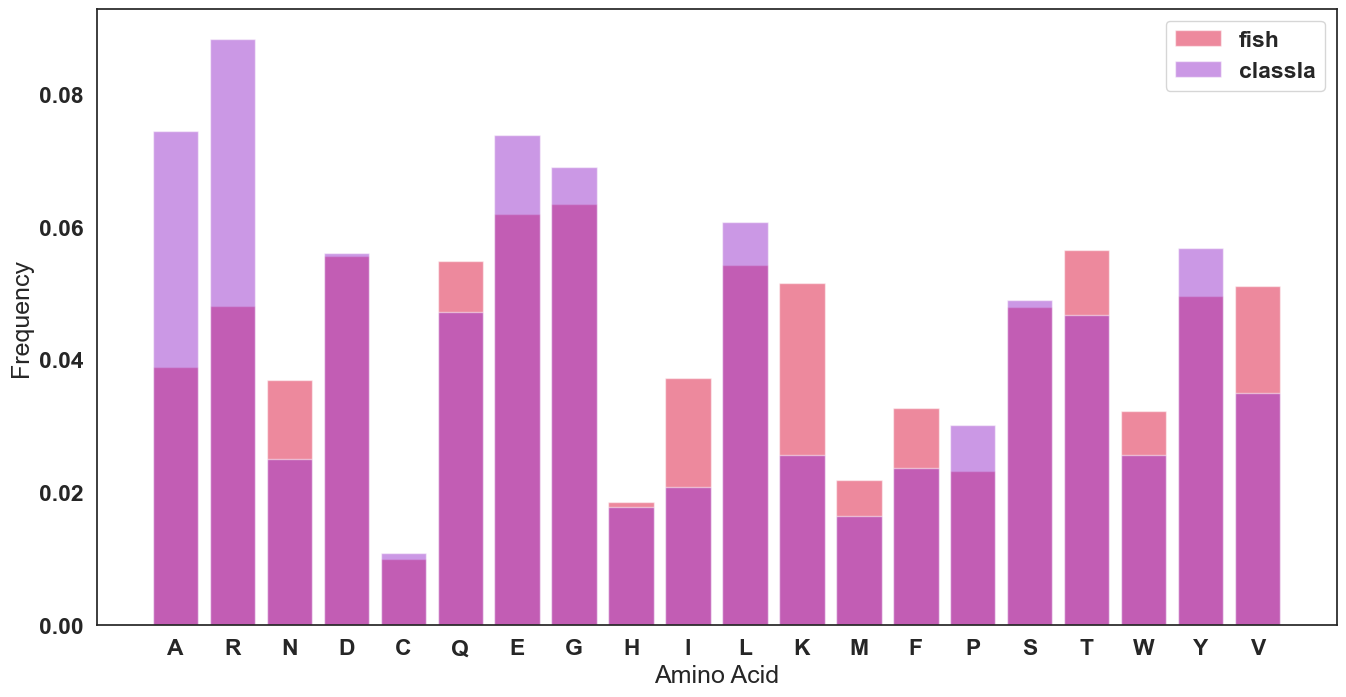

In [29]:
# Need to get back just our sequences of interest.
colors=['crimson','darkorchid']
seq1 = sub_seqF.loc[ref_sub[ref_sub[len(sub_matF)-1] == 0].index]
seq2 = sub_seqF.loc[ref_sub[ref_sub[len(sub_matF)-1] == 1].index]

freq_all1  = aims.full_AA_freq(seq1,my_AA_key)
freq_all2  = aims.full_AA_freq(seq2,my_AA_key)

fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(16,8))
ax[0,0].bar(np.arange(len(freq_all1)),freq_all1, color=colors[0],alpha=0.5)
ax[0,0].bar(np.arange(len(freq_all2)),freq_all2,color=colors[1],alpha=0.5)
xax=pl.setp(ax,xticks=np.arange(20),xticklabels=fin_key)
ax[0,0].legend([label[0],label[1]])
#ax[1,0].legend([label[2],label[3]])2
pl.ylabel('Frequency')
pl.xlabel('Amino Acid')
pl.savefig(outputDir+'/AIMS_AAnetProb.pdf',format='pdf')

# Section 17.2: Statistical Significance for Amino Acid Frequencies

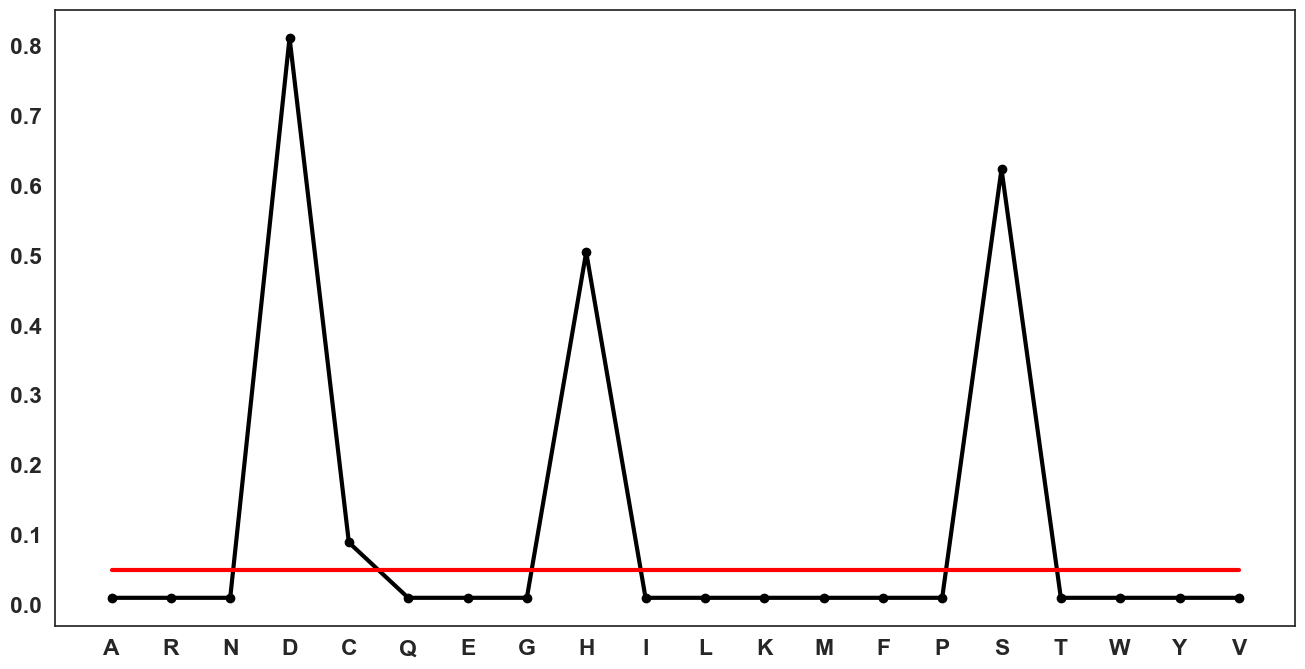

In [30]:
data1 = seqF[ref_sub[ref_sub[len(sub_matF)-1] == 0].index]
data2 = seqF[ref_sub[ref_sub[len(sub_matF)-1] == 1].index]

p_freq = aims.do_statistics(data1,data2,num_reps=100,test='function',test_func=aims.full_AA_freq,my_AA_key=my_AA_key)

p_df = np.transpose(pandas.DataFrame(p_freq))
p_df.columns = AA_key
p_df_fin = p_df[fin_key]

fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(16,8))
pl.plot(p_df_fin.values[0],marker='o',linewidth=3,color='black')
pl.plot(np.arange(20),np.ones(20)*0.05,linewidth=3,color='red')
xax=pl.setp(ax,xticks=np.arange(20),xticklabels=fin_key)
pl.savefig(outputDir+'/AIMS_AAnetProb_pval.pdf',format='pdf')

# Section 17.3 Plot the Digram Frequencies Per Sequence (or per AA)
There can occasionally be interesting information in these digram patterns, particularly if there are notabe differences between populations.

Note, while the matrix could possibly appear symmetric, it need not be so. The y-axis gives the first amino acid in the digram, the x-axis gives the second. So on the x,y coordinate map, E (x-axis) and D (y-axis) gives the frequency of the digram DE.

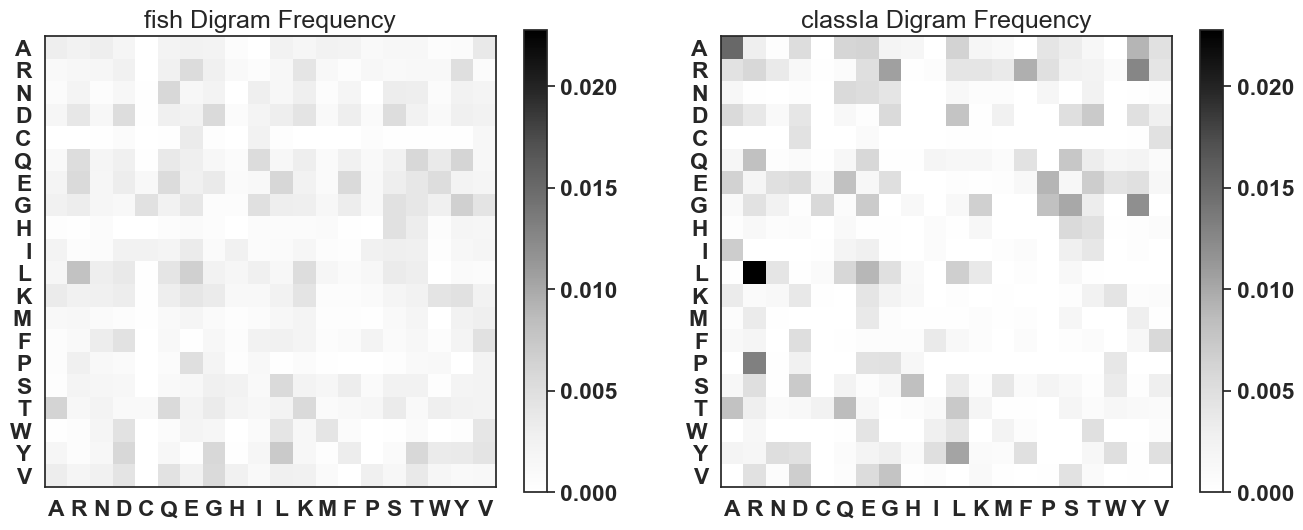

In [31]:
fig, ax = pl.subplots(int(len(label)/2), 2,squeeze=False,figsize=(16,12))

digram_all1 = aims.digram_AA_freq(seq1,my_AA_key)
digram_all2 = aims.digram_AA_freq(seq2,my_AA_key)

plot_max = np.max([np.max(digram_all1),np.max(digram_all2)])

ax[0,0].set_title(str(label[0])+ ' Digram Frequency')
ax[0,1].set_title(str(label[1])+ ' Digram Frequency')

x1 = ax[0,0].imshow(digram_all1,  cmap = cm.Greys,vmin=0,vmax=plot_max)
x2 = ax[0,1].imshow(digram_all2,  cmap = cm.Greys,vmin=0,vmax=plot_max)

xax=pl.setp(ax[0,0],xticks=np.arange(20),xticklabels=fin_key)
yax=pl.setp(ax[0,0],yticks=np.arange(20),yticklabels=fin_key)
xax=pl.setp(ax[0,1],xticks=np.arange(20),xticklabels=fin_key)
yax=pl.setp(ax[0,1],yticks=np.arange(20),yticklabels=fin_key)

fig.colorbar(x1, ax=ax[0, 0], shrink=0.5)
fig.colorbar(x2, ax=ax[0, 1], shrink=0.5)
pl.savefig(outputDir+'/AIMS_digram_sep.pdf',format='pdf')

# Section 17.4 Digram Amino Acid Differences

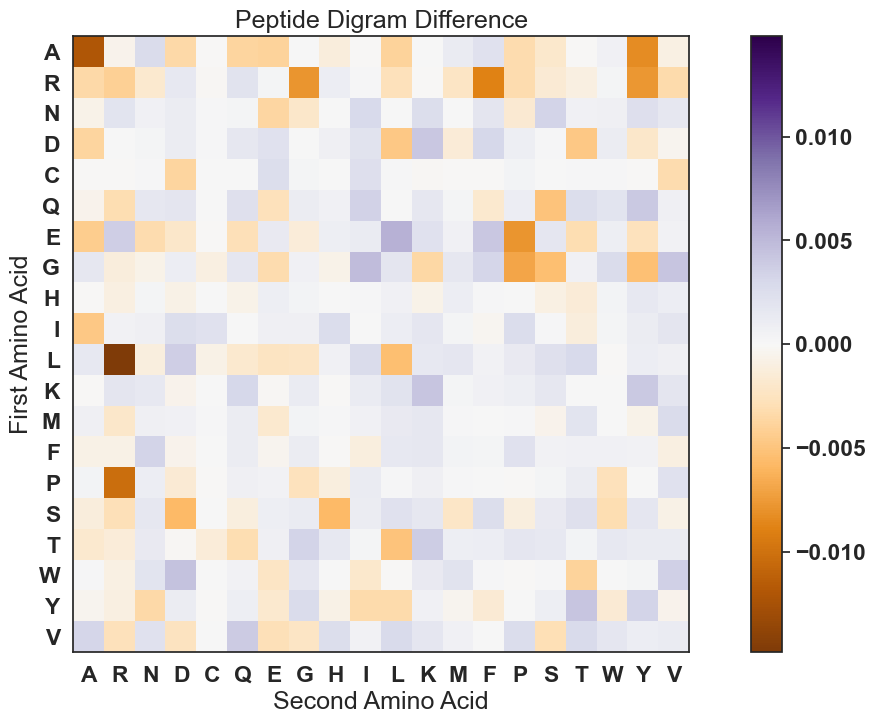

In [32]:
# Look at the difference in these digram frequencies
# For now, hard to say if these are necessarily significant, 
# more downstream analysis is needed to tease out conclusions
fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(16,8))
pl.title('Peptide Digram Difference')
min_temp = np.min(digram_all2-digram_all1)
max_temp = np.max(digram_all2-digram_all1)
if abs(min_temp) > abs(max_temp):
    propMin = min_temp
    propMax = -min_temp
elif abs(max_temp) > abs(min_temp):
    propMin = -max_temp
    propMax = max_temp
else:
    propMin = min_temp
    propMax = max_temp
zzz = pl.imshow(digram_all1-digram_all2, vmin = propMin, vmax = propMax, cmap = cm.PuOr)
xax=pl.setp(ax,xticks=np.arange(20),xticklabels=fin_key)
yax=pl.setp(ax,yticks=np.arange(20),yticklabels=fin_key)
ax[0,0].set_ylabel('First Amino Acid')
ax[0,0].set_xlabel('Second Amino Acid')
pl.colorbar(zzz)
pl.savefig(outputDir+'/AIMS_digramDiff.pdf',format='pdf')

# Section 17.5: Digram Amino Acid Difference Stat. Sig.
- Again, exceptionally slow. num_reps=2 by default for now but need much higher for actual statistics
- Code is embarassingly parallelizable. TODO: Implement numba for this code

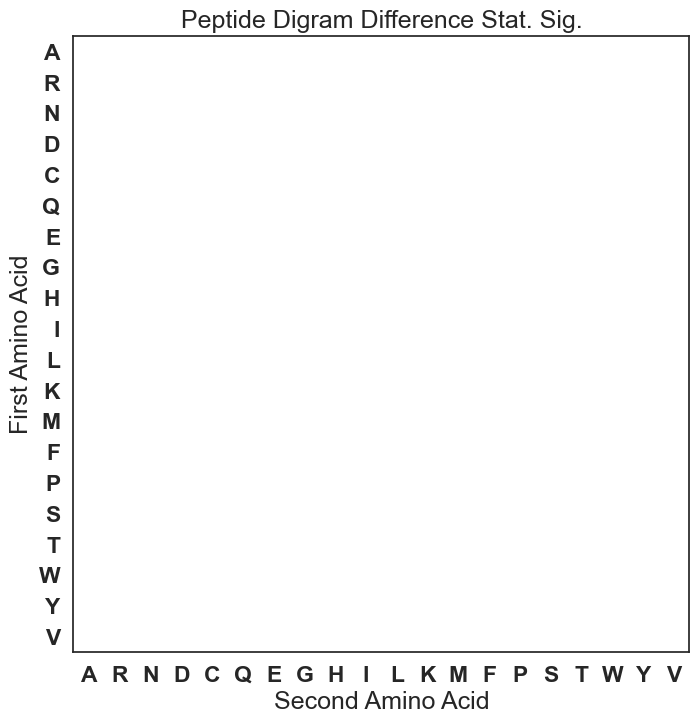

In [35]:
data1 = seqF[ref_sub[ref_sub[len(sub_matF)-1] == 0].index]
data2 = seqF[ref_sub[ref_sub[len(sub_matF)-1] == 1].index]

p_digram = aims.do_statistics(data1,data2,num_reps=2,test='function',test_func=aims.digram_AA_freq,my_AA_key=my_AA_key)

dim1, dim2 = np.shape(p_digram)
alpha = 0.05

empty_mat_digram = np.zeros((dim1,dim2))
for a in np.arange(dim1):
    for b in np.arange(dim2):
        if p_digram[a,b] < alpha:
            empty_mat_digram[a,b] = 1

empty_dig = pandas.DataFrame(empty_mat_digram)
empty_dig.columns = AA_key; empty_dig.index = AA_key
empty_digF = empty_dig[fin_key].loc[fin_key]

fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(10,8))
pl.title('Peptide Digram Difference Stat. Sig.')
x= pl.imshow(empty_digF,cmap=cm.Greys)
xax=pl.setp(ax,xticks=np.arange(20),xticklabels=fin_key)
xax=pl.setp(ax,yticks=np.arange(20),yticklabels=fin_key)
ax[0,0].set_ylabel('First Amino Acid')
ax[0,0].set_xlabel('Second Amino Acid')
pl.savefig(outputDir+'/digram_diff_sig.pdf',format='pdf')